<a href="https://colab.research.google.com/github/Churrascooo/Mimic-IV-ACE-mortality-prediction/blob/main/ACE_mortality_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Predicción de mortalidad en ACS geriátrico (ICU)

Este colab construye el superdataset desde cero en una sola pasada lineal:
1. Carga de tablas MIMIC-IV
2. Filtrado de cohorte (ICU, ≥60 años, ACS)
3. Construcción del superdataset (merge progresivo sobre las 6444 filas)
4. Target: mortalidad intrahospitalaria
5. Modelos: Random Forest, CatBoost, XGBoost, TF-IDF + MLP, BioClinical + LoRa

## 0. Entorno y rutas

In [ ]:
# 0.1 === Importación de librerías y rutas necesarias para correr el código ===

#IMPORTANTE: Para correr el código, se debe utilizar la GPU T4 de Colab
#Durante la ejecución, aparecerá un mensaje diciendo que conviene utilizar la CPU
#default. Esto se debe ignorar, ya que la GPU se aprovecha con el BioClinicalBert + LoRA

from google.colab import drive
drive.mount('/content/drive')

import os
import gc
import warnings
import numpy as np
import pandas as pd

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import pairwise_distances

# === Rutas ===
RAW_DIR   = "/content/drive/MyDrive"           # CSVs de MIMIC-IV
NOTES_DIR = "/content/drive/MyDrive"           # radiology.csv.gz
OUT_DIR   = "/content/drive/MyDrive/mimic_outputs"
os.makedirs(OUT_DIR, exist_ok=True)

def load_raw(name, usecols=None):
    """Carga una tabla MIMIC-IV desde RAW_DIR."""
    return pd.read_csv(
        os.path.join(RAW_DIR, f"{name}.csv.gz"),
        compression="gzip", usecols=usecols
    )

def check_unique(df, key="subject_id", name="df"):
    """Garantiza 1 fila por key. Lanza AssertionError si hay duplicados."""
    n, u = len(df), df[key].nunique(dropna=False)
    assert n == u, f"[{name}] duplicados: {n-u:,} (filas={n:,}, únicos={u:,})"
    print(f"[{name}] OK — {n:,} filas, {n:,} {key} únicos")

Mounted at /content/drive


## 1. Carga de tablas MIMIC-IV

Se cargan SOLO las columnas estrictamente necesarias, para así reducir memoria.

In [ ]:
# 1.1 === Tablas ===

patients = load_raw("patients",
    usecols=["subject_id", "gender", "anchor_age", "anchor_year"])

admissions = load_raw("admissions",
    usecols=["subject_id", "hadm_id", "admittime", "dischtime",
             "deathtime", "hospital_expire_flag"])

icustays = load_raw("icustays",
    usecols=["subject_id", "hadm_id", "stay_id", "intime", "outtime"])

diagnoses = load_raw("diagnoses_icd",
    usecols=["subject_id", "hadm_id", "seq_num", "icd_code", "icd_version"])

icd_dict = load_raw("d_icd_diagnoses",
    usecols=["icd_code", "icd_version", "long_title"])

# Conversión datetime
for col in ["admittime", "dischtime", "deathtime"]:
    admissions[col] = pd.to_datetime(admissions[col], errors="coerce")

for col in ["intime", "outtime"]:
    icustays[col] = pd.to_datetime(icustays[col], errors="coerce")

print("Tablas cargadas:")
for name, df in [
    ("patients", patients),
    ("admissions", admissions),
    ("icustays", icustays),
    ("diagnoses", diagnoses),
    ("icd_dict", icd_dict),

]:
    print(f"  {name:15s}: {df.shape}")

Tablas cargadas:
  patients       : (364627, 4)
  admissions     : (546028, 6)
  icustays       : (94458, 5)
  diagnoses      : (6364488, 5)
  icd_dict       : (112107, 3)


## 2. Construcción de la cohorte base

**Criterios de inclusión:**
- Una fila por paciente
- Se usa el último indice de hospitalización (hamd_id)
- Se usa la primera estancia en UCI de ese índice de hospitalización (intime_icu)
- Paciente con al menos una estancia en UCI
- Edad ≥ 60 años al momento de admisión
- Al menos un diagnóstico ICD de ACS (STEMI, NSTEMI, SCA)

**Códigos ACS:**
- ICD-10: I21 (STEMI/NSTEMI agudo), I22 (reinfarto), I23 (complicaciones), I24 (otros SCA agudos)
- ICD-9: 410 (infarto agudo), 411 (otras formas agudas isquémicas)

In [ ]:
# 2.1 === Identificar hospitalizaciones con diagnóstico ACS ===

#Códigos ICD
ICD10_ACS = ("I21", "I22", "I23", "I24") #Códigos ICD versión 10
ICD9_ACS  = ("410", "411") #Códigos ICD versión 9

dx_with_desc = diagnoses.merge(icd_dict, on=["icd_code", "icd_version"], how="left")

is_acs = (
    ((dx_with_desc["icd_version"] == 10) &
     dx_with_desc["icd_code"].astype(str).str.startswith(ICD10_ACS))
    |
    ((dx_with_desc["icd_version"] == 9) &
     dx_with_desc["icd_code"].astype(str).str.startswith(ICD9_ACS))
)

hadm_acs = (
    dx_with_desc.loc[is_acs, ["subject_id", "hadm_id"]]
    .drop_duplicates()
)

print(f"Hospitalizaciones con diagnóstico ACS: {len(hadm_acs):,}")

Hospitalizaciones con diagnóstico ACS: 21,909


In [ ]:
# 2.2 === Construir cohorte: última UCI + edad + ACS ===

#Recordatorio:
# - 1 fila por paciente (no se repiten)
# - La unidad índice es la última hospitalización de cada paciente
# - Se filtra si esa hospitalización índice tuvo diagnóstico ACS

#Flujo:
# - Identificar la última hospitalización con UCI para cada paciente
# - Agregar información de admisión y paciente
# - Calcular edad al ingreso y filtrar edad >= 60
# - Filtrar si esa hospitalización índice tuvo diagnóstico ACS

temp_cohort_icu_admit = (
    icustays
    .merge(admissions, on=["subject_id", "hadm_id"], how="inner")
)

last_hosp_with_icu = (
    temp_cohort_icu_admit
    .sort_values(["subject_id", "admittime", "intime"])
    .groupby("subject_id", as_index=False)
    .last()
)

print(f"Pacientes con última hospitalización UCI: {last_hosp_with_icu['subject_id'].nunique():,}")

cohort = last_hosp_with_icu.merge(
    patients,
    on="subject_id",
    how="inner"
)

cohort["age_at_admit"] = (
    cohort["anchor_age"] +
    (cohort["admittime"].dt.year - cohort["anchor_year"])
)

cohort = cohort.loc[cohort["age_at_admit"] >= 60].copy()

print(f"Pacientes UCI >=60: {cohort['subject_id'].nunique():,}")

cohort = cohort.merge(
    hadm_acs,
    on=["subject_id", "hadm_id"],
    how="inner"
)

check_unique(cohort, key="subject_id", name="cohort")

print(f"Pacientes ACS + última UCI + edad >=60: {len(cohort):,}")
print(f"Edad mín/máx: {cohort['age_at_admit'].min():.0f} / {cohort['age_at_admit'].max():.0f}")
print(f"Mortalidad (hospital_expire_flag): {cohort['hospital_expire_flag'].mean():.1%}")

Pacientes con última hospitalización UCI: 65,366
Pacientes UCI >=60: 43,346
[cohort] OK — 6,644 filas, 6,644 subject_id únicos
Pacientes ACS + última UCI + edad >=60: 6,644
Edad mín/máx: 60 / 100
Mortalidad (hospital_expire_flag): 21.4%


In [ ]:
# 2.3 === Definir el superdataset ===

#Las columnas que se mantienen de la cohorte base son:
# - subject_id, hadm_id (De las más importantes)
# - admittime (Para la ventana temporal)
# - gender (Dato demográfico)
# - age_at_admit (Dato demográfico)
# - hospital_expire_flag (Target)

#Las columnas que se descartan:
# - anchor_age, anchor_year (Solo se usan para calcular age_at_admit)
# - stay_id (Identifica estancia UCI)
# - intime, outtime (Temporales de la UCI, no se usan como feature base)
# - dischtime, deathtime (Leakage, ya que es post evento)

KEEP_BASE = [
    "subject_id", "hadm_id", "admittime",
    "gender", "age_at_admit",
    "hospital_expire_flag"
]

ds = cohort[KEEP_BASE].copy()

#Codificación de género
ds["gender"] = ds["gender"].map({"M": 1, "F": 0})

#Validaciones
assert ds["gender"].notna().all(), "Hay valores de gender no mapeados o nulos"
assert ds["hospital_expire_flag"].isin([0, 1]).all(), "Target tiene valores distintos de 0/1"

ds["gender"] = ds["gender"].astype(int)
ds["hospital_expire_flag"] = ds["hospital_expire_flag"].astype(int)

check_unique(ds, key="subject_id", name="superdataset — base")

print("\nDistribución del target:")
print(ds["hospital_expire_flag"].value_counts())
print(ds["hospital_expire_flag"].value_counts(normalize=True).round(4))

print("\nColumnas actuales:", ds.columns.tolist())
print(ds.head(3))

[superdataset — base] OK — 6,644 filas, 6,644 subject_id únicos

Distribución del target:
hospital_expire_flag
0    5222
1    1422
Name: count, dtype: int64
hospital_expire_flag
0    0.786
1    0.214
Name: proportion, dtype: float64

Columnas actuales: ['subject_id', 'hadm_id', 'admittime', 'gender', 'age_at_admit', 'hospital_expire_flag']
   subject_id   hadm_id           admittime  gender  age_at_admit  \
0    10000980  26913865 2189-06-27 07:38:00       0            76   
1    10002495  24982426 2141-05-22 20:17:00       1            81   
2    10004422  21255400 2111-01-15 14:55:00       1            78   

   hospital_expire_flag  
0                     0  
1                     0  
2                     0  


## 3. Enriquecimiento progresivo del superdataset

Cada bloque agrega columnas al mismo DataFrame `ds`.
Antes y después de cada merge se valida que sigue siendo 1 fila por `subject_id`, con la función `check_unique`.

In [ ]:
# 3.1 === Número de estancias UCI (n_icu_stays) ===

#Se cuentan cuántas estancias UCI tuvo cada paciente en la hospitalización índice
#No se incluye 'icu_los_days' porque es leakage, el LOS se conoce solo al alta

icu_stays_count = (
    icustays
    .merge(ds[["subject_id", "hadm_id"]], on=["subject_id", "hadm_id"], how="inner")
    .groupby("subject_id", as_index=False)
    .agg(n_icu_stays=("stay_id", "nunique"))
)

ds = ds.merge(icu_stays_count, on="subject_id", how="left")
ds["n_icu_stays"] = ds["n_icu_stays"].fillna(0).astype(int)

check_unique(ds, key="subject_id", name="superdataset — + n_icu_stays")
print(ds[["n_icu_stays"]].describe())

[superdataset — + n_icu_stays] OK — 6,644 filas, 6,644 subject_id únicos
       n_icu_stays
count  6644.000000
mean      1.150963
std       0.438543
min       1.000000
25%       1.000000
50%       1.000000
75%       1.000000
max       9.000000


In [ ]:
# 3.1.1 === Calcular intime_icu y unir a ds ===

#intime_icu = Es el momento de ingreso a UCI en la hospitalización índice
#Es la referencia temporal correcta para todas las ventanas de 48h
#Si el paciente tiene múltiples stays UCI en la misma hospitalización,
#se toma la primera intime (la más temprana)

intime_icu = (
    icustays
    .merge(
        ds[["subject_id", "hadm_id"]],
        on=["subject_id", "hadm_id"],
        how="inner"
    )
    .sort_values(["subject_id", "intime"])
    .groupby("subject_id", as_index=False)
    .first()[["subject_id", "intime"]]
    .rename(columns={"intime": "intime_icu"})
)

ds = ds.merge(intime_icu, on="subject_id", how="left")

n_missing = ds["intime_icu"].isna().sum()
print(f"Pacientes sin intime_icu: {n_missing}")

check_unique(ds, key="subject_id", name="superdataset — + intime_icu")
print(ds[["admittime", "intime_icu"]].describe())

Pacientes sin intime_icu: 0
[superdataset — + intime_icu] OK — 6,644 filas, 6,644 subject_id únicos
                           admittime                     intime_icu
count                           6644                           6644
mean   2153-03-18 07:11:35.996388352  2153-03-19 21:43:04.597531648
min              2110-01-18 14:46:00            2110-01-18 14:46:27
25%    2132-07-06 09:01:44.999999488            2132-07-06 17:07:36
50%              2152-12-22 06:19:00            2152-12-22 09:36:02
75%              2173-01-22 13:30:00            2173-01-22 13:57:30
max              2211-12-27 06:05:00            2211-12-27 12:54:39


In [ ]:
# 3.2 === Diagnósticos, número de dx únicos (excluidos los ACS) ===

#Se excluyen los propios códigos ACS para no crear leakage conceptual
#En este caso, todos los pacientes tienen ACS por definición de la cohorte

dx_clean = (
    diagnoses
    .merge(icd_dict, on=["icd_code", "icd_version"], how="left")
    .dropna(subset=["icd_code", "long_title"])
)

#Excluir ACS
is_acs_dx = (
    ((dx_clean["icd_version"] == 10) &
     dx_clean["icd_code"].astype(str).str.startswith(ICD10_ACS))
    |
    ((dx_clean["icd_version"] == 9) &
     dx_clean["icd_code"].astype(str).str.startswith(ICD9_ACS))
)

dx_no_acs = dx_clean.loc[~is_acs_dx].copy()

#Filtrar solo hospitalizaciones de la cohorte
dx_cohort = dx_no_acs.merge(
    ds[["subject_id", "hadm_id"]],
    on=["subject_id", "hadm_id"],
    how="inner"
)

#Validar que no quedaron códigos ACS
assert not (
    ((dx_cohort["icd_version"] == 10) &
     dx_cohort["icd_code"].astype(str).str.startswith(ICD10_ACS))
    |
    ((dx_cohort["icd_version"] == 9) &
     dx_cohort["icd_code"].astype(str).str.startswith(ICD9_ACS))
).any(), "Todavía quedaron códigos ACS en dx_cohort"

dx_features = (
    dx_cohort
    .groupby("subject_id", as_index=False)
    .agg(n_unique_dx=("icd_code", "nunique"))
)

ds = ds.merge(dx_features, on="subject_id", how="left")
ds["n_unique_dx"] = ds["n_unique_dx"].fillna(0).astype(int)

check_unique(ds, key="subject_id", name="superdataset — + n_unique_dx")
print(ds[["n_unique_dx"]].describe())

[superdataset — + n_unique_dx] OK — 6,644 filas, 6,644 subject_id únicos
       n_unique_dx
count  6644.000000
mean     20.427303
std       9.001529
min       1.000000
25%      14.000000
50%      20.000000
75%      27.000000
max      38.000000


In [ ]:
# 3.3 === Comorbilidades clínicas, flags por prefijos ICD ===

#Se construyen flags binarios de comorbilidades relevantes en pacientes
#geriátricos con ACS, usando prefijos ICD-10/9.

#Nota metodológica:
# - Estas variables están inspiradas en grupos clínicos tipo Elixhauser,
#   pero no corresponden a una implementación completa/oficial del índice
# - Cada flag = 1 si el paciente tiene al menos un código del grupo.

COMORBIDITY_FLAGS = {
    "comorb_chf":        {"icd10": ("I50",), "icd9": ("428",)},
    "comorb_diabetes":   {"icd10": ("E10", "E11", "E12", "E13"), "icd9": ("250",)},
    "comorb_renal":      {"icd10": ("N18", "N19"), "icd9": ("585", "586")},
    "comorb_copd":       {"icd10": ("J44",), "icd9": ("496",)},
    "comorb_hypert":     {"icd10": ("I10", "I11", "I12", "I13"), "icd9": ("401", "402", "403", "404")},
    "comorb_afib":       {"icd10": ("I48",), "icd9": ("4273",)},
    "comorb_stroke":     {"icd10": ("I63", "I64"), "icd9": ("434", "436")},
    "comorb_cancer":     {"icd10": ("C",), "icd9": ("140", "141", "142", "143", "144",
                                                    "145", "146", "147", "148", "149",
                                                    "150", "151", "152", "153", "154",
                                                    "155", "156", "157", "158", "159",
                                                    "160", "161", "162", "163", "164",
                                                    "165", "170", "171", "172", "174",
                                                    "175", "179", "180", "181", "182",
                                                    "183", "184", "185", "186", "187",
                                                    "188", "189", "190", "191", "192",
                                                    "193", "194", "195")},
}

dx_str = dx_cohort.copy()
dx_str["icd_code"] = dx_str["icd_code"].astype(str)

for flag, codes in COMORBIDITY_FLAGS.items():
    mask_10 = (
        (dx_str["icd_version"] == 10) &
        dx_str["icd_code"].str.startswith(codes["icd10"])
    )

    mask_9 = (
        (dx_str["icd_version"] == 9) &
        dx_str["icd_code"].str.startswith(codes["icd9"])
    )

    flag_patients = (
        dx_str.loc[mask_10 | mask_9, ["subject_id"]]
        .drop_duplicates()
        .assign(**{flag: 1})
    )

    ds = ds.merge(flag_patients, on="subject_id", how="left")
    ds[flag] = ds[flag].fillna(0).astype(int)

#Validaciones
check_unique(ds, key="subject_id", name="superdataset — + comorbidity flags")

comorb_cols = list(COMORBIDITY_FLAGS.keys())

assert ds[comorb_cols].isin([0, 1]).all().all(), \
    "Hay flags de comorbilidad distintos de 0/1"

print("\nPrevalencia de comorbilidades:")
print(ds[comorb_cols].mean().round(3))

[superdataset — + comorbidity flags] OK — 6,644 filas, 6,644 subject_id únicos

Prevalencia de comorbilidades:
comorb_chf         0.503
comorb_diabetes    0.429
comorb_renal       0.347
comorb_copd        0.149
comorb_hypert      0.814
comorb_afib        0.431
comorb_stroke      0.055
comorb_cancer      0.099
dtype: float64


In [ ]:
# 3.4 === Prescripciones primeras 48h desde intime_icu ===

#Prescriptions no se carga en la Sección 1 porque es muy grande (~400 MB RAM)
#Se lee aquí en chunks, filtrando subject_id + ventana 48h dentro del loop

COHORT_SUBJECTS = set(ds["subject_id"].unique())

print("Leyendo prescriptions en chunks — filtrando cohorte + ventana 48h dentro del loop...")

rx_chunks = []

for chunk in pd.read_csv(
    os.path.join(RAW_DIR, "prescriptions.csv.gz"),
    compression="gzip",
    usecols=["subject_id", "hadm_id", "starttime", "drug"],
    chunksize=500_000,
    dtype={"subject_id": "int32", "hadm_id": "int32"},
):
    #Paso 1: Filtrar por cohorte
    chunk = chunk[chunk["subject_id"].isin(COHORT_SUBJECTS)]
    if len(chunk) == 0:
        continue

    #Paso 2: Convertir datetime
    chunk["starttime"] = pd.to_datetime(chunk["starttime"], errors="coerce")

    #Paso 3: Hacer merge con intime_icu
    chunk = chunk.merge(
        ds[["subject_id", "hadm_id", "intime_icu"]],
        on=["subject_id", "hadm_id"],
        how="inner"
    )

    #Paso 4: Filtrar ventana 48h dentro del chunk
    chunk = chunk[
        chunk["starttime"].notna() &
        (chunk["starttime"] >= chunk["intime_icu"]) &
        (chunk["starttime"] <= chunk["intime_icu"] + pd.Timedelta(hours=48))
    ]

    if len(chunk) > 0:
        rx_chunks.append(chunk[["subject_id", "drug"]].copy())

rx_48h = pd.concat(rx_chunks, ignore_index=True)
del rx_chunks
gc.collect()

print(f"  Filas acumuladas tras filtro: {len(rx_48h):,}")

rx_features = (
    rx_48h
    .dropna(subset=["drug"])
    .drop_duplicates()
    .groupby("subject_id", as_index=False)
    .agg(n_unique_drugs_48h=("drug", "nunique"))
)

del rx_48h
gc.collect()

ds = ds.merge(rx_features, on="subject_id", how="left")
ds["n_unique_drugs_48h"] = ds["n_unique_drugs_48h"].fillna(0).astype(int)

check_unique(ds, key="subject_id", name="superdataset — + n_unique_drugs_48h")
print(ds[["n_unique_drugs_48h"]].describe())

Leyendo prescriptions en chunks — filtrando cohorte + ventana 48h dentro del loop...
  Filas acumuladas tras filtro: 350,729
[superdataset — + n_unique_drugs_48h] OK — 6,644 filas, 6,644 subject_id únicos
       n_unique_drugs_48h
count         6644.000000
mean            30.919627
std             12.336720
min              0.000000
25%             21.000000
50%             30.000000
75%             41.000000
max             75.000000


In [ ]:
#3.4.1 === Laboratorios, primeras 48h desde intime_icu
#Este bloque se demora unos 10 minutos en correr

#Conjunto de subject_id de la cohorte (filtro rápido dentro de chunks)
COHORT_SUBJECTS = set(ds["subject_id"].unique())
ADMIT_LOOKUP = ds.set_index("subject_id")[["hadm_id", "intime_icu"]].copy()

LAB_ITEMS = {
    "trop_i":      51002,
    "trop_t":      51003,
    "creatinine":  50912,
    "hemoglobin":  51222,
    "lactate":     50813,
    "glucose_lab": 50931,
    "bnp":         50963,
    "nt_probnp":   50949,
    "sodium":      50983,
    "potassium":   50971,
    "hematocrit":  51221,
    "bun":         51006,
}

LAB_ITEM_IDS = set(LAB_ITEMS.values())
LAB_ID_TO_NAME = {v: k for k, v in LAB_ITEMS.items()}

print("Leyendo labevents en chunks — filtrando cohorte + ventana 48h desde intime_icu...")

lab_chunks = []

for chunk in pd.read_csv(
    os.path.join(RAW_DIR, "labevents.csv.gz"),
    compression="gzip",
    usecols=["subject_id", "hadm_id", "itemid", "charttime", "valuenum"],
    chunksize=500_000,
    dtype={
        "subject_id": "int32",
        "hadm_id":    "float32",
        "itemid":     "int32",
        "valuenum":   "float32",
    },
):
    chunk = chunk[
        chunk["subject_id"].isin(COHORT_SUBJECTS) &
        chunk["itemid"].isin(LAB_ITEM_IDS)
    ]
    if len(chunk) == 0:
        continue

    chunk["hadm_id"]   = chunk["hadm_id"].astype("Int32")
    chunk["charttime"] = pd.to_datetime(chunk["charttime"], errors="coerce")

    chunk = chunk.merge(
        ds[["subject_id", "hadm_id", "intime_icu"]],
        on=["subject_id", "hadm_id"],
        how="inner"
    )

    chunk = chunk[
        chunk["charttime"].notna() &
        (chunk["charttime"] >= chunk["intime_icu"]) &
        (chunk["charttime"] <= chunk["intime_icu"] + pd.Timedelta(hours=48))
    ]

    if len(chunk) > 0:
        lab_chunks.append(
            chunk[["subject_id", "itemid", "charttime", "valuenum"]].copy()
        )

labs_48h = pd.concat(lab_chunks, ignore_index=True)
del lab_chunks
gc.collect()

print(f"  Filas acumuladas tras filtro: {len(labs_48h):,}")

labs_48h["lab_name"] = labs_48h["itemid"].map(LAB_ID_TO_NAME)
labs_48h = labs_48h.sort_values(["subject_id", "lab_name", "charttime"])

lab_agg = (
    labs_48h
    .dropna(subset=["valuenum"])
    .groupby(["subject_id", "lab_name"], as_index=False)
    .agg(
        first_val=("valuenum", "first"),
        max_val=("valuenum",   "max"),
    )
)

del labs_48h
gc.collect()

lab_first = (
    lab_agg[["subject_id", "lab_name", "first_val"]]
    .pivot(index="subject_id", columns="lab_name", values="first_val")
    .add_prefix("lab_first_")
    .reset_index()
)

lab_max = (
    lab_agg[["subject_id", "lab_name", "max_val"]]
    .pivot(index="subject_id", columns="lab_name", values="max_val")
    .add_prefix("lab_max_")
    .reset_index()
)

del lab_agg
gc.collect()

ds = ds.merge(lab_first, on="subject_id", how="left")
ds = ds.merge(lab_max,   on="subject_id", how="left")

del lab_first, lab_max
gc.collect()

#Flags binarios de si fue medido en 48h
for name in LAB_ITEMS:
    col_first = f"lab_first_{name}"
    col_flag  = f"lab_measured_{name}"
    if col_first in ds.columns:
        ds[col_flag] = ds[col_first].notna().astype("int8")

lab_cols_continuous = [
    c for c in ds.columns
    if c.startswith("lab_first_") or c.startswith("lab_max_")
]

lab_cols_flag = [
    c for c in ds.columns
    if c.startswith("lab_measured_")
]

for col in lab_cols_flag:
    ds[col] = ds[col].fillna(0).astype("int8")

check_unique(ds, key="subject_id", name="superdataset — + labs 48h")

print(f"\nColumnas de laboratorio agregadas: {len([c for c in ds.columns if c.startswith('lab_')])}")
print("\nCobertura (% pacientes con al menos 1 medición en 48h):")
for name in LAB_ITEMS:
    flag_col = f"lab_measured_{name}"
    if flag_col in ds.columns:
        print(f"  {name:<20s}: {ds[flag_col].mean():.1%}")

print("\nVerificación NaN tras imputación:")
nan_counts = ds[lab_cols_continuous].isna().sum()
print(nan_counts[nan_counts > 0] if nan_counts.any() else "  Sin NaN en columnas de laboratorio")

Leyendo labevents en chunks — filtrando cohorte + ventana 48h desde intime_icu...


/tmp/ipykernel_1542/2082026973.py:50: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  chunk["charttime"] = pd.to_datetime(chunk["charttime"], errors="coerce")


  Filas acumuladas tras filtro: 104,527
[superdataset — + labs 48h] OK — 6,644 filas, 6,644 subject_id únicos

Columnas de laboratorio agregadas: 33

Cobertura (% pacientes con al menos 1 medición en 48h):
  trop_t              : 31.2%
  creatinine          : 49.1%
  hemoglobin          : 49.0%
  lactate             : 35.7%
  glucose_lab         : 49.0%
  bnp                 : 3.2%
  nt_probnp           : 0.5%
  sodium              : 49.0%
  potassium           : 49.0%
  hematocrit          : 49.0%
  bun                 : 49.1%

Verificación NaN tras imputación:
lab_first_bnp            6430
lab_first_bun            3385
lab_first_creatinine     3385
lab_first_glucose_lab    3388
lab_first_hematocrit     3386
lab_first_hemoglobin     3386
lab_first_lactate        4275
lab_first_nt_probnp      6612
lab_first_potassium      3387
lab_first_sodium         3386
lab_first_trop_t         4572
lab_max_bnp              6430
lab_max_bun              3385
lab_max_creatinine       3385
lab_max_glu

In [ ]:
# 3.4.2 ===  Signos vitales, primeras 48h desde intime_icu ===
#Este bloque se demora unos 10 minutos en correr

VITAL_ITEMS = {
    "hr":     [220045],
    "sbp":    [220179, 220050],
    "dbp":    [220180, 220051],
    "map":    [220052, 220181],
    "spo2":   [220277],
    "rr":     [220210],
    "temp_c": [223762],
    "temp_f": [223761],
}

VITAL_ITEM_IDS = set(item for ids in VITAL_ITEMS.values() for item in ids)

VITAL_ID_TO_NAME = {}
for name, ids in VITAL_ITEMS.items():
    for i in ids:
        VITAL_ID_TO_NAME[i] = name

print("\nLeyendo chartevents en chunks — filtrando cohorte + ventana 48h desde intime_icu...")
print("(Este archivo es grande, puede tardar 5-15 min dependiendo del Drive)")

vital_chunks = []

for chunk in pd.read_csv(
    os.path.join(RAW_DIR, "chartevents.csv.gz"),
    compression="gzip",
    usecols=["subject_id", "hadm_id", "itemid", "charttime", "valuenum"],
    chunksize=300_000,
    dtype={
        "subject_id": "int32",
        "hadm_id":    "float32",
        "itemid":     "int32",
        "valuenum":   "float32",
    },
):
    chunk = chunk[
        chunk["subject_id"].isin(COHORT_SUBJECTS) &
        chunk["itemid"].isin(VITAL_ITEM_IDS)
    ]
    if len(chunk) == 0:
        continue

    chunk["hadm_id"]   = chunk["hadm_id"].astype("Int32")
    chunk["charttime"] = pd.to_datetime(chunk["charttime"], errors="coerce")

    chunk = chunk.merge(
        ds[["subject_id", "hadm_id", "intime_icu"]],
        on=["subject_id", "hadm_id"],
        how="inner"
    )

    chunk = chunk[
        chunk["charttime"].notna() &
        (chunk["charttime"] >= chunk["intime_icu"]) &
        (chunk["charttime"] <= chunk["intime_icu"] + pd.Timedelta(hours=48)) &
        chunk["valuenum"].notna() &
        (chunk["valuenum"] > 0)
    ]

    if len(chunk) > 0:
        vital_chunks.append(
            chunk[["subject_id", "itemid", "valuenum"]].copy()
        )

vitals_48h = pd.concat(vital_chunks, ignore_index=True)
del vital_chunks
gc.collect()

print(f"  Filas acumuladas tras filtro: {len(vitals_48h):,}")

#Convertir Fahrenheit a Celsius y unificar nombre
mask_f = vitals_48h["itemid"] == 223761
vitals_48h.loc[mask_f, "valuenum"] = (vitals_48h.loc[mask_f, "valuenum"] - 32) * 5 / 9

vitals_48h["vital_name"] = vitals_48h["itemid"].map(VITAL_ID_TO_NAME)
vitals_48h["vital_name"] = vitals_48h["vital_name"].replace("temp_f", "temp_c")

#Agregar media, mínimo, máximo
vital_agg = (
    vitals_48h
    .groupby(["subject_id", "vital_name"], as_index=False)
    .agg(
        mean_val=("valuenum", "mean"),
        min_val=("valuenum",  "min"),
        max_val=("valuenum",  "max"),
    )
)

del vitals_48h
gc.collect()

#Pivot a wide
vital_mean = (
    vital_agg[["subject_id", "vital_name", "mean_val"]]
    .pivot(index="subject_id", columns="vital_name", values="mean_val")
    .add_prefix("vital_mean_")
    .reset_index()
)

vital_min = (
    vital_agg[["subject_id", "vital_name", "min_val"]]
    .pivot(index="subject_id", columns="vital_name", values="min_val")
    .add_prefix("vital_min_")
    .reset_index()
)

vital_max = (
    vital_agg[["subject_id", "vital_name", "max_val"]]
    .pivot(index="subject_id", columns="vital_name", values="max_val")
    .add_prefix("vital_max_")
    .reset_index()
)

del vital_agg
gc.collect()

ds = ds.merge(vital_mean, on="subject_id", how="left")
ds = ds.merge(vital_min,  on="subject_id", how="left")
ds = ds.merge(vital_max,  on="subject_id", how="left")

del vital_mean, vital_min, vital_max
gc.collect()

#Shock index (FC media / PAS media), predictor validado en ACS
if "vital_mean_hr" in ds.columns and "vital_mean_sbp" in ds.columns:
    ds["vital_shock_index"] = (
        ds["vital_mean_hr"] / ds["vital_mean_sbp"].replace(0, np.nan)
    )

vital_cols_continuous = [
    c for c in ds.columns
    if c.startswith("vital_mean_") or
       c.startswith("vital_min_")  or
       c.startswith("vital_max_")
]

check_unique(ds, key="subject_id", name="superdataset — + vitals 48h")

print(f"\nColumnas de signos vitales agregadas: {len([c for c in ds.columns if c.startswith('vital_')])}")
print("\nCobertura (% pacientes con al menos 1 registro en 48h):")
for name in set(v for v in VITAL_ID_TO_NAME.values() if v != "temp_f"):
    col = f"vital_mean_{name}"
    if col in ds.columns:
        print(f"  {name:<8s}: {ds[col].notna().mean():.1%}")

print("\nVerificación NaN tras imputación:")
nan_counts = ds[vital_cols_continuous + ["vital_shock_index"]].isna().sum()
print(nan_counts[nan_counts > 0] if nan_counts.any() else "  Sin NaN en columnas de vitales")


Leyendo chartevents en chunks — filtrando cohorte + ventana 48h desde intime_icu...
(Este archivo es grande, puede tardar 5-15 min dependiendo del Drive)


/tmp/ipykernel_1542/367302239.py:47: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  chunk["charttime"] = pd.to_datetime(chunk["charttime"], errors="coerce")


  Filas acumuladas tras filtro: 925,071
[superdataset — + vitals 48h] OK — 6,644 filas, 6,644 subject_id únicos

Columnas de signos vitales agregadas: 22

Cobertura (% pacientes con al menos 1 registro en 48h):
  hr      : 49.5%
  dbp     : 49.4%
  temp_c  : 48.6%
  spo2    : 49.4%
  sbp     : 49.4%
  rr      : 49.4%
  map     : 49.4%

Verificación NaN tras imputación:
vital_mean_dbp       3364
vital_mean_hr        3354
vital_mean_map       3364
vital_mean_rr        3360
vital_mean_sbp       3364
vital_mean_spo2      3364
vital_mean_temp_c    3415
vital_min_dbp        3364
vital_min_hr         3354
vital_min_map        3364
vital_min_rr         3360
vital_min_sbp        3364
vital_min_spo2       3364
vital_min_temp_c     3415
vital_max_dbp        3364
vital_max_hr         3354
vital_max_map        3364
vital_max_rr         3360
vital_max_sbp        3364
vital_max_spo2       3364
vital_max_temp_c     3415
vital_shock_index    3364
dtype: int64


In [ ]:
# 3.4.3 Ventilación mecánica invasiva, primeras 48h desde intime_icu ===
#Este bloque se demora unos 10 minutos en correr

#Objetivo:
# - Crear flag_mech_vent_48h = 1 si existe evidencia de ventilación mecánica
#   invasiva dentro de las primeras 48h desde el ingreso a UCI

#Decisión metodológica:
# - No se usa procedures_icd porque no entrega timestamp clínico preciso
# - Sí se usa chartevents porque tiene charttime, compatible con la ventana 48h

MECH_VENT_ITEMIDS = {
    226732,  # O2 Delivery Device(s)
    223849,  # Ventilator Mode
    229314,  # Ventilator Mode (Hamilton)
}

INVASIVE_VENT_MODES = {
    "(S) CMV",
    "APRV",
    "APRV/Biphasic+ApnPress",
    "APRV/Biphasic+ApnVol",
    "APV (cmv)",
    "Ambient",
    "Apnea Ventilation",
    "CMV",
    "CMV/ASSIST",
    "CMV/ASSIST/AutoFlow",
    "CMV/AutoFlow",
    "CPAP/PPS",
    "CPAP/PSV",
    "CPAP/PSV+Apn TCPL",
    "CPAP/PSV+ApnPres",
    "CPAP/PSV+ApnVol",
    "MMV",
    "MMV/AutoFlow",
    "MMV/PSV",
    "MMV/PSV/AutoFlow",
    "P-CMV",
    "PCV+",
    "PCV+/PSV",
    "PCV+Assist",
    "PRES/AC",
    "PRVC/AC",
    "PRVC/SIMV",
    "PSV/SBT",
    "SIMV",
    "SIMV/AutoFlow",
    "SIMV/PRES",
    "SIMV/PSV",
    "SIMV/PSV/AutoFlow",
    "SIMV/VOL",
    "SYNCHRON MASTER",
    "SYNCHRON SLAVE",
    "VOL/AC",
    "APV (simv)",
    "P-SIMV",
    "VS",
    "ASV",
}

INVASIVE_O2_DEVICES = {
    "Endotracheal tube",
}

print("Leyendo chartevents — ventilación mecánica invasiva 48h desde intime_icu...")

vent_chunks = []

for chunk in pd.read_csv(
    os.path.join(RAW_DIR, "chartevents.csv.gz"),
    compression="gzip",
    usecols=["subject_id", "hadm_id", "itemid", "charttime", "value"],
    chunksize=300_000,
    dtype={
        "subject_id": "int32",
        "hadm_id": "float32",
        "itemid": "int32",
        "value": "string",
    },
):
    #Filtrar cohorte e itemids respiratorios relevantes
    chunk = chunk[
        chunk["subject_id"].isin(COHORT_SUBJECTS) &
        chunk["itemid"].isin(MECH_VENT_ITEMIDS)
    ]

    if len(chunk) == 0:
        continue

    #Tipos
    chunk["hadm_id"] = chunk["hadm_id"].astype("Int32")
    chunk["charttime"] = pd.to_datetime(chunk["charttime"], errors="coerce")
    chunk["value_clean"] = chunk["value"].astype(str).str.strip()

    #Unir intime_icu
    chunk = chunk.merge(
        ds[["subject_id", "hadm_id", "intime_icu"]],
        on=["subject_id", "hadm_id"],
        how="inner"
    )

    #Filtrar ventana 48h desde ingreso a UCI
    chunk = chunk[
        chunk["charttime"].notna() &
        (chunk["charttime"] >= chunk["intime_icu"]) &
        (chunk["charttime"] <= chunk["intime_icu"] + pd.Timedelta(hours=48))
    ]

    if len(chunk) == 0:
        continue

    #Evidencia de ventilación mecánica invasiva
    #1. Dispositivo: tubo endotraqueal
    #2. Modo ventilatorio invasivo
    mask_device = (
        (chunk["itemid"] == 226732) &
        (chunk["value_clean"].isin(INVASIVE_O2_DEVICES))
    )

    mask_mode = (
        (chunk["itemid"].isin([223849, 229314])) &
        (chunk["value_clean"].isin(INVASIVE_VENT_MODES))
    )

    chunk["flag_mech_vent_48h"] = (mask_device | mask_mode).astype(int)

    if chunk["flag_mech_vent_48h"].sum() > 0:
        vent_chunks.append(
            chunk.loc[
                chunk["flag_mech_vent_48h"] == 1,
                ["subject_id", "flag_mech_vent_48h"]
            ].copy()
        )

if len(vent_chunks) > 0:
    vent_48h = pd.concat(vent_chunks, ignore_index=True)

    vent_feature = (
        vent_48h
        .groupby("subject_id", as_index=False)
        .agg(flag_mech_vent_48h=("flag_mech_vent_48h", "max"))
    )

    del vent_48h, vent_chunks
else:
    vent_feature = pd.DataFrame({
        "subject_id": ds["subject_id"],
        "flag_mech_vent_48h": 0
    })

gc.collect()

#Unir al superdataset
ds = ds.merge(vent_feature, on="subject_id", how="left")
ds["flag_mech_vent_48h"] = ds["flag_mech_vent_48h"].fillna(0).astype(int)

#Validaciones
check_unique(ds, key="subject_id", name="superdataset — + flag_mech_vent_48h")

assert ds["flag_mech_vent_48h"].isin([0, 1]).all(), \
    "flag_mech_vent_48h tiene valores distintos de 0/1"

print("\nPrevalencia ventilación mecánica invasiva 48h:")
print(ds["flag_mech_vent_48h"].value_counts().sort_index())
print(ds["flag_mech_vent_48h"].mean().round(4))

Leyendo chartevents — ventilación mecánica invasiva 48h desde intime_icu...
[superdataset — + flag_mech_vent_48h] OK — 6,644 filas, 6,644 subject_id únicos

Prevalencia ventilación mecánica invasiva 48h:
flag_mech_vent_48h
0    4956
1    1688
Name: count, dtype: int64
0.2541


In [ ]:
# 3.5 === Tipo de ACS (STEMI vs NSTEMI vs otro) ===

#Se clasifica el tipo de ACS más severo presente en la hospitalización índice

#Prioridad:
#1. STEMI
#2. NSTEMI
#3. Otro ACS

#Features:
# - acs_type_stemi = 1 si el paciente tuvo STEMI
# - acs_type_nstemi = 1 si el paciente tuvo NSTEMI y NO tuvo STEMI

#Si ambos son 0, el paciente tiene otro ACS: I22/I23/I24 o 411

#Recalcular ACS sobre dx_with_desc para evitar desalineación de índices
is_acs_dx_full = (
    ((dx_with_desc["icd_version"] == 10) &
     dx_with_desc["icd_code"].astype(str).str.startswith(ICD10_ACS))
    |
    ((dx_with_desc["icd_version"] == 9) &
     dx_with_desc["icd_code"].astype(str).str.startswith(ICD9_ACS))
)

dx_acs_cohort = (
    dx_with_desc
    .loc[is_acs_dx_full]
    .merge(ds[["subject_id", "hadm_id"]], on=["subject_id", "hadm_id"], how="inner")
    .copy()
)

dx_acs_cohort["icd_code"] = dx_acs_cohort["icd_code"].astype(str)

#STEMI:
#ICD-10: I210, I211, I212, I213, I219
#ICD-9: 4100, 4101, 4102, 4103, 4104, 4105, 4106, 4108, 4109

stemi_mask = (
    ((dx_acs_cohort["icd_version"] == 10) &
     dx_acs_cohort["icd_code"].str.match(r"^(I210|I211|I212|I213|I219)"))
    |
    ((dx_acs_cohort["icd_version"] == 9) &
     dx_acs_cohort["icd_code"].str.match(r"^410[0-689]"))
)

#NSTEMI:
#ICD-10: I214
#ICD-9: 4107
nstemi_mask = (
    ((dx_acs_cohort["icd_version"] == 10) &
     dx_acs_cohort["icd_code"].str.startswith("I214"))
    |
    ((dx_acs_cohort["icd_version"] == 9) &
     dx_acs_cohort["icd_code"].str.startswith("4107"))
)

stemi_patients = (
    dx_acs_cohort.loc[stemi_mask, ["subject_id"]]
    .drop_duplicates()
    .assign(acs_type_stemi=1)
)

nstemi_patients = (
    dx_acs_cohort.loc[nstemi_mask, ["subject_id"]]
    .drop_duplicates()
    .assign(acs_type_nstemi_raw=1)
)

ds = ds.merge(stemi_patients, on="subject_id", how="left")
ds = ds.merge(nstemi_patients, on="subject_id", how="left")

ds["acs_type_stemi"] = ds["acs_type_stemi"].fillna(0).astype(int)
ds["acs_type_nstemi_raw"] = ds["acs_type_nstemi_raw"].fillna(0).astype(int)

#Se aplica prioridad, si tuvo STEMI, queda clasificado como STEMI aunque también tenga código NSTEMI
ds["acs_type_nstemi"] = (
    (ds["acs_type_nstemi_raw"] == 1) &
    (ds["acs_type_stemi"] == 0)
).astype(int)

ds = ds.drop(columns=["acs_type_nstemi_raw"])

#Validaciones
check_unique(ds, key="subject_id", name="superdataset — + acs_type")

assert ds[["acs_type_stemi", "acs_type_nstemi"]].isin([0, 1]).all().all(), \
    "Hay valores distintos de 0/1 en tipo ACS"

assert not ((ds["acs_type_stemi"] == 1) & (ds["acs_type_nstemi"] == 1)).any(), \
    "Hay pacientes clasificados como STEMI y NSTEMI al mismo tiempo"

print("\nDistribución tipo ACS:")
print(ds[["acs_type_stemi", "acs_type_nstemi"]].value_counts())

[superdataset — + acs_type] OK — 6,644 filas, 6,644 subject_id únicos

Distribución tipo ACS:
acs_type_stemi  acs_type_nstemi
0               1                  3017
                0                  2399
1               0                  1228
Name: count, dtype: int64


In [ ]:
# 3.6 === Nota clínica, primera nota radiológica en 48h ===

#Radiology no se carga en la Sección 1 porque puede pesar mucho (~800 MB–1.5 GB en RAM)
#Se lee aquí en chunks filtrando subject_id + ventana 48h dentro del loop

print("Leyendo radiology en chunks — filtrando cohorte + ventana 48h dentro del loop...")

rad_chunks = []

for chunk in pd.read_csv(
    os.path.join(NOTES_DIR, "radiology.csv.gz"),
    compression="gzip",
    usecols=["subject_id", "hadm_id", "charttime", "text"],
    chunksize=100_000,          # chunk pequeño porque "text" es columna pesada
    dtype={"subject_id": "int32", "hadm_id": "float32"},
):
    #Paso 1: Filtrar por cohorte
    chunk = chunk[chunk["subject_id"].isin(COHORT_SUBJECTS)]
    if len(chunk) == 0:
        continue

    #Paso 2: Tipos
    chunk["hadm_id"]   = chunk["hadm_id"].astype("Int32")
    chunk["charttime"] = pd.to_datetime(chunk["charttime"], errors="coerce")

    #Paso 3: Mergear intime_icu
    chunk = chunk.merge(
        ds[["subject_id", "hadm_id", "intime_icu"]],
        on=["subject_id", "hadm_id"],
        how="inner"
    )

    #Paso 4: Filtrar ventana 48h dentro del chunk
    chunk = chunk[
        chunk["charttime"].notna() &
        (chunk["charttime"] >= chunk["intime_icu"]) &
        (chunk["charttime"] <= chunk["intime_icu"] + pd.Timedelta(hours=48))
    ]

    if len(chunk) > 0:
        rad_chunks.append(chunk[["subject_id", "charttime", "text"]].copy())

rad_48h = pd.concat(rad_chunks, ignore_index=True)
del rad_chunks
gc.collect()

print(f"  Filas acumuladas tras filtro: {len(rad_48h):,}")

#Tomar la primera nota por paciente dentro de la ventana
first_note = (
    rad_48h
    .sort_values(["subject_id", "charttime"])
    .groupby("subject_id", as_index=False)
    .first()[["subject_id", "text"]]
    .rename(columns={"text": "text_note"})
)

del rad_48h
gc.collect()

ds = ds.merge(first_note, on="subject_id", how="left")
ds["text_note"] = ds["text_note"].fillna("").astype(str)

has_note = (ds["text_note"].str.len() > 0).sum()

check_unique(ds, key="subject_id", name="superdataset — + text_note")
print(f"\nPacientes con nota en 48h: {has_note:,} / {len(ds):,} ({has_note/len(ds):.1%})")

Leyendo radiology en chunks — filtrando cohorte + ventana 48h dentro del loop...
  Filas acumuladas tras filtro: 5,650
[superdataset — + text_note] OK — 6,644 filas, 6,644 subject_id únicos

Pacientes con nota en 48h: 2,086 / 6,644 (31.4%)


In [ ]:
# 3.7 === Resumen del superdataset ===

#Checkeos finales
check_unique(ds, key="subject_id", name="superdataset final")

assert ds["hospital_expire_flag"].isin([0, 1]).all(), \
    "El target tiene valores distintos de 0/1"

print("=" * 55)
print("SUPERDATASET FINAL")
print("=" * 55)

print(f"Filas (pacientes)  : {len(ds):,}")
print(f"Columnas totales   : {len(ds.columns)}")

print()
print("Columnas:")
for col in ds.columns:
    dtype = str(ds[col].dtype)
    nulls = ds[col].isna().sum()
    print(f"  {col:<25s}  {dtype:<10s}  nulls={nulls}")

print()
print("Target (hospital_expire_flag) — conteo:")
print(ds["hospital_expire_flag"].value_counts().sort_index())

print()
print("Target (hospital_expire_flag) — proporción:")
print(ds["hospital_expire_flag"].value_counts(normalize=True).sort_index().round(3))

print()
print("Descripción features numéricas:")
num_cols = [
    "age_at_admit",
    "n_icu_stays",
    "n_unique_dx",
    "n_unique_drugs_48h"
]

print(ds[num_cols].describe().round(2))

[superdataset final] OK — 6,644 filas, 6,644 subject_id únicos
SUPERDATASET FINAL
Filas (pacientes)  : 6,644
Columnas totales   : 77

Columnas:
  subject_id                 int64       nulls=0
  hadm_id                    int64       nulls=0
  admittime                  datetime64[ns]  nulls=0
  gender                     int64       nulls=0
  age_at_admit               int64       nulls=0
  hospital_expire_flag       int64       nulls=0
  n_icu_stays                int64       nulls=0
  intime_icu                 datetime64[ns]  nulls=0
  n_unique_dx                int64       nulls=0
  comorb_chf                 int64       nulls=0
  comorb_diabetes            int64       nulls=0
  comorb_renal               int64       nulls=0
  comorb_copd                int64       nulls=0
  comorb_hypert              int64       nulls=0
  comorb_afib                int64       nulls=0
  comorb_stroke              int64       nulls=0
  comorb_cancer              int64       nulls=0
  n_unique_drug

In [ ]:
# 3.8 === Guardar superdataset ACS-UCI no pareado ===

#Contiene la cohorte ACS-UCI completa

OUT_SUPERDATASET = os.path.join(
    OUT_DIR,
    "superdataset_acs_icu_unmatched.parquet"
)

ds.to_parquet(OUT_SUPERDATASET, index=False)

print("Guardado:", OUT_SUPERDATASET)
print("Dimensiones:", ds.shape)
print("Pacientes únicos:", ds["subject_id"].nunique())
print("Target:")
print(ds["hospital_expire_flag"].value_counts().sort_index())

Guardado: /content/drive/MyDrive/mimic_outputs/superdataset_acs_icu_unmatched.parquet
Dimensiones: (6644, 77)
Pacientes únicos: 6644
Target:
hospital_expire_flag
0    5222
1    1422
Name: count, dtype: int64


## 4. Preparación para modelos

**Separación clara de responsabilidades:**
- `COLS_ID`     → claves, nunca entran a modelos
- `COLS_TARGET` → target
- `COLS_TEXT`   → solo para TF-IDF + MLP
- `COLS_TABULAR`→ features para RF, CatBoost y XGBoost



In [ ]:
# 4.1 === Definición explícita de roles de columnas ===

#Este bloque prepara las variables para modelado usando el superdataset ACS-UCI
#Desde este punto en adelante, los modelos deben usar ds_model, no ds_final

warnings.filterwarnings("ignore", category=FutureWarning)

#Dataset que se usará en todos los modelos
ds_model = ds.copy()

COLS_ID = [
    "subject_id",
    "hadm_id",
    "admittime",
    "intime_icu"
]

COLS_TARGET = [
    "hospital_expire_flag"
]

COLS_TEXT = [
    "text_note"
]

#Se detectan columnas nuevas directamente desde ds_model
COLS_NEW_LABS   = [c for c in ds_model.columns if c.startswith("lab_")]
COLS_NEW_VITALS = [c for c in ds_model.columns if c.startswith("vital_")]

#Procedimientos / soporte respiratorio temprano
#Se mantiene flag_mech_vent_48h porque fue reconstruida desde chartevents
#usando charttime dentro de las primeras 48h desde intime_icu
COLS_NEW_PROC = [
    "flag_mech_vent_48h"
]

COLS_TABULAR = (
    [
        "gender",
        "age_at_admit",
        "n_icu_stays",
        "n_unique_dx",
        "n_unique_drugs_48h",
        "acs_type_stemi",
        "acs_type_nstemi",
    ]
    + list(COMORBIDITY_FLAGS.keys())
    + COLS_NEW_LABS
    + COLS_NEW_VITALS
    + COLS_NEW_PROC
)

#Verificacion que todas las columnas existen en ds_model
missing = [c for c in COLS_TABULAR if c not in ds_model.columns]
assert not missing, f"Columnas faltantes en ds_model: {missing}"

assert ds_model["hospital_expire_flag"].isin([0, 1]).all(), \
    "El target tiene valores distintos de 0/1"

assert "flag_mech_vent_48h" in ds_model.columns, \
    "flag_mech_vent_48h no existe en ds_model"

assert ds_model["flag_mech_vent_48h"].isin([0, 1]).all(), \
    "flag_mech_vent_48h tiene valores distintos de 0/1"

print("\n=== RESUMEN FEATURES SUPERDATASET NO PAREADO ===")
print(f"Dataset usado     : {ds_model.shape}")
print(f"Pacientes únicos  : {ds_model['subject_id'].nunique()}")
print(f"Laboratorios      : {len(COLS_NEW_LABS)} columnas")
print(f"Signos vitales    : {len(COLS_NEW_VITALS)} columnas")
print(f"Procedimientos    : {len(COLS_NEW_PROC)} columnas")
print(f"COLS_TABULAR total: {len(COLS_TABULAR)} features")

print("\nDistribución target:")
print(ds_model["hospital_expire_flag"].value_counts().sort_index())

print("\nProporción target:")
print(ds_model["hospital_expire_flag"].value_counts(normalize=True).sort_index().round(3))

print("\nDistribución flag_mech_vent_48h:")
print(ds_model["flag_mech_vent_48h"].value_counts().sort_index())

print("\nProporción flag_mech_vent_48h:")
print(ds_model["flag_mech_vent_48h"].mean().round(4))


=== RESUMEN FEATURES SUPERDATASET NO PAREADO ===
Dataset usado     : (6644, 77)
Pacientes únicos  : 6644
Laboratorios      : 33 columnas
Signos vitales    : 22 columnas
Procedimientos    : 1 columnas
COLS_TABULAR total: 71 features

Distribución target:
hospital_expire_flag
0    5222
1    1422
Name: count, dtype: int64

Proporción target:
hospital_expire_flag
0    0.786
1    0.214
Name: proportion, dtype: float64

Distribución flag_mech_vent_48h:
flag_mech_vent_48h
0    4956
1    1688
Name: count, dtype: int64

Proporción flag_mech_vent_48h:
0.2541


## 5. Modelos

Evaluación con `StratifiedKFold(n_splits=5)` para respetar la proporción de clases en cada fold.
Métricas: AUC-ROC, Sensibilidad, Especificidad, PPV.

In [ ]:
# 5.1 === Importación de librerías para modelos ===

#Para Random Forest
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, roc_curve, auc, confusion_matrix
from sklearn.model_selection import StratifiedKFold
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

In [ ]:
# 5.2 === Preparación para los modelos ===

def eval_fold(y_test, y_proba, threshold=0.5):
    """Calcula AUC, sensibilidad, especificidad y PPV para un fold."""

    y_pred = (y_proba >= threshold).astype(int)

    auc_val = roc_auc_score(y_test, y_proba)

    tn, fp, fn, tp = confusion_matrix(
        y_test,
        y_pred,
        labels=[0, 1]
    ).ravel()

    sens = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    ppv  = tp / (tp + fp) if (tp + fp) > 0 else 0.0

    return {
        "auc": auc_val,
        "sens": sens,
        "spec": spec,
        "ppv": ppv
    }


def print_results(name, scores):
    """Imprime resultados promedio de validación cruzada."""

    print(f"\n{'─'*40}")
    print(f"  {name} (5-Fold CV)")
    print(f"{'─'*40}")

    for metric in ["auc", "sens", "spec", "ppv"]:
        vals = [s[metric] for s in scores]
        print(f"  {metric.upper():<6}: {np.mean(vals):.3f} ± {np.std(vals):.3f}")


SKF = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [ ]:
# 5.1 === Random Forest ===

#Modelo tabular con imputación por mediana dentro de cada fold

#Justificación metodológica:
# - Labs y signos vitales pueden tener valores faltantes
# - No usamos fillna(0), porque 0 puede no ser clínicamente válido
# - La imputación se aprende solo con el train fold para evitar leakage

#Variables tabulares y target
X_tab = ds_model[COLS_TABULAR].copy()
y = ds_model[COLS_TARGET].squeeze().astype(int)

#Gender ya viene como 0/1 desde el pipeline
#Se debe solo convertir si todavía es texto
if "gender" in X_tab.columns:
    if X_tab["gender"].dtype == object:
        X_tab["gender"] = X_tab["gender"].map({"M": 1, "F": 0})
    X_tab["gender"] = pd.to_numeric(X_tab["gender"], errors="coerce")

#Verificación
print("gender dtype :", X_tab["gender"].dtype)
print("gender NaN   :", X_tab["gender"].isna().sum())
print("gender únicos:", X_tab["gender"].unique())

#Validaciones básicas
assert len(X_tab) == len(y), "X_tab e y tienen distinto tamaño"
assert y.isin([0, 1]).all(), "y tiene valores distintos de 0/1"
assert X_tab["gender"].isna().sum() == 0, "gender tiene NaN — revisar pipeline"

rf_scores = []

#Para guardar predicciones out-of-fold de todos los pacientes
y_true_rf_all = []
y_proba_rf_all = []

rf_final = None

for fold, (tr, te) in enumerate(SKF.split(X_tab, y), 1):
    print(f"Fold {fold}", end="  ")

    rf = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", RandomForestClassifier(
            n_estimators=300,
            min_samples_leaf=20,
            class_weight="balanced",
            n_jobs=1,
            random_state=42
        ))
    ])

    rf.fit(X_tab.iloc[tr], y.iloc[tr])

    y_proba = rf.predict_proba(X_tab.iloc[te])[:, 1]

    fold_scores = eval_fold(y.iloc[te].values, y_proba)
    rf_scores.append(fold_scores)

    y_true_rf_all.extend(y.iloc[te].values)
    y_proba_rf_all.extend(y_proba)

    print(f"AUC={fold_scores['auc']:.3f}")

    #Guardar último modelo entrenado para feature importance
    if fold == SKF.n_splits:
        rf_final = rf

#Convertir a arrays
y_true_rf_all = np.array(y_true_rf_all)
y_proba_rf_all = np.array(y_proba_rf_all)

print_results("Random Forest", rf_scores)

print(f"\nAUC global out-of-fold RF: {roc_auc_score(y_true_rf_all, y_proba_rf_all):.3f}")

gender dtype : int64
gender NaN   : 0
gender únicos: [0 1]
Fold 1  AUC=0.797
Fold 2  AUC=0.826
Fold 3  AUC=0.785
Fold 4  AUC=0.809
Fold 5  AUC=0.807

────────────────────────────────────────
  Random Forest (5-Fold CV)
────────────────────────────────────────
  AUC   : 0.805 ± 0.014
  SENS  : 0.720 ± 0.030
  SPEC  : 0.718 ± 0.016
  PPV   : 0.410 ± 0.007

AUC global out-of-fold RF: 0.805


In [ ]:
##Importacion Catboost
!pip install catboost
from catboost import CatBoostClassifier

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 11.0 MB/s eta 0:00:00


In [ ]:
# 5.2 === CatBoost===

#Modelo tabular con manejo nativo de valores faltantes

#Justificación metodológica:
# - Labs y signos vitales pueden tener valores faltantes
# - CatBoost puede manejar valores NaN directamente durante el entrenamiento
# - No se realiza imputación previa, evitando calcular estadísticas fuera del train fold
# - Se balancean automáticamente las clases debido al desbalance del target

#Variables tabulares y target (ya definidas en el bloque RF)
X_cb = X_tab.copy()
y_cb = y.copy()

#Convertir gender a numérico por si acaso
if "gender" in X_cb.columns and X_cb["gender"].dtype == object:
    X_cb["gender"] = X_cb["gender"].replace({"M": 1, "F": 0})
X_cb["gender"] = pd.to_numeric(X_cb["gender"], errors="coerce")

#Asegurar que todo sea numérico
for col in X_cb.columns:
    X_cb[col] = pd.to_numeric(X_cb[col], errors="coerce")

#Verificación rápida
assert len(X_cb) == len(y_cb)
assert y_cb.isin([0, 1]).all()
assert X_cb["gender"].isna().sum() == 0, "`gender` tiene NaN — revisar pipeline"

cb_scores = []
y_true_cb_all, y_proba_cb_all = [], []
cb_final = None

for fold, (tr, te) in enumerate(SKF.split(X_cb, y_cb), 1):
    print(f"Fold {fold}", end="  ")

    cb = CatBoostClassifier(
        iterations=500,
        depth=6,
        learning_rate=0.05,
        loss_function="Logloss",
        eval_metric="AUC",
        auto_class_weights="Balanced",
        random_seed=42,
        thread_count=1, #Esto es para que cada vez que se itere el colab arrojen los mismos resultados
        verbose=False
    )

    cb.fit(X_cb.iloc[tr], y_cb.iloc[tr])

    y_proba = cb.predict_proba(X_cb.iloc[te])[:, 1]

    fold_scores = eval_fold(y_cb.iloc[te].values, y_proba)
    cb_scores.append(fold_scores)

    y_true_cb_all.extend(y_cb.iloc[te].values)
    y_proba_cb_all.extend(y_proba)

    print(f"AUC={fold_scores['auc']:.3f}")

    if fold == SKF.n_splits:
        cb_final = cb  #guardar último modelo para inspección

#Métrica OOF global
y_true_cb_all = np.array(y_true_cb_all)
y_proba_cb_all = np.array(y_proba_cb_all)

print_results("CatBoost", cb_scores)
print(f"\nAUC global out-of-fold CatBoost: {roc_auc_score(y_true_cb_all, y_proba_cb_all):.3f}")

Fold 1  AUC=0.815
Fold 2  AUC=0.833
Fold 3  AUC=0.806
Fold 4  AUC=0.814
Fold 5  AUC=0.805

────────────────────────────────────────
  CatBoost (5-Fold CV)
────────────────────────────────────────
  AUC   : 0.815 ± 0.010
  SENS  : 0.658 ± 0.028
  SPEC  : 0.779 ± 0.010
  PPV   : 0.448 ± 0.008

AUC global out-of-fold CatBoost: 0.814


In [ ]:
!pip -q install xgboost

from xgboost import XGBClassifier
from xgboost import XGBClassifier

In [ ]:
# 5.3 === XGBoost ===

#Modelo tabular con manejo nativo de valores faltantes

#Justificación metodológica:
# - Labs y signos vitales pueden contener valores NaN
# - XGBoost puede manejar estos valores directamente durante el entrenamiento
# - El desbalance de clases se compensa dentro de cada fold mediante
# - scale_pos_weight, calculado solo con los datos del train fold

#Preparar datos (ya provenientes del bloque RF)
X_xgb = X_tab.copy()
y_xgb = y.copy()

#Asegurar gender como numérico
if "gender" in X_xgb.columns and X_xgb["gender"].dtype == object:
    X_xgb["gender"] = X_xgb["gender"].replace({"M": 1, "F": 0})
X_xgb["gender"] = pd.to_numeric(X_xgb["gender"], errors="coerce")

#Convertir todo a numérico
for col in X_xgb.columns:
    X_xgb[col] = pd.to_numeric(X_xgb[col], errors="coerce")

#Verificación rápida
assert len(X_xgb) == len(y_xgb)
assert y_xgb.isin([0, 1]).all()
assert X_xgb["gender"].isna().sum() == 0

xgb_scores = []
y_true_xgb_all, y_proba_xgb_all = [], []
xgb_final = None

for fold, (tr, te) in enumerate(SKF.split(X_xgb, y_xgb), 1):
    print(f"Fold {fold}", end="  ")

    X_tr, X_te = X_xgb.iloc[tr], X_xgb.iloc[te]
    y_tr, y_te = y_xgb.iloc[tr], y_xgb.iloc[te]

    #Compensar desbalance: ratio negativos / positivos en el fold de entrenamiento
    scale_pos_weight = (y_tr == 0).sum() / (y_tr == 1).sum()

    xgb = XGBClassifier(
        n_estimators=500,
        max_depth=4,
        learning_rate=0.03,
        subsample=0.8,
        colsample_bytree=0.8,
        min_child_weight=5,
        reg_lambda=1.0,
        objective="binary:logistic",
        eval_metric="auc",
        tree_method="hist",
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        n_jobs=1
    )

    xgb.fit(X_tr, y_tr)

    y_proba = xgb.predict_proba(X_te)[:, 1]

    fold_scores = eval_fold(y_te.values, y_proba)
    xgb_scores.append(fold_scores)

    y_true_xgb_all.extend(y_te.values)
    y_proba_xgb_all.extend(y_proba)

    print(f"AUC={fold_scores['auc']:.3f}")

    if fold == SKF.n_splits:
        xgb_final = xgb  #guardar último modelo

#Métrica OOF global
y_true_xgb_all = np.array(y_true_xgb_all)
y_proba_xgb_all = np.array(y_proba_xgb_all)

print_results("XGBoost", xgb_scores)
print(f"\nAUC global out-of-fold XGBoost: {roc_auc_score(y_true_xgb_all, y_proba_xgb_all):.3f}")

Fold 1  AUC=0.812
Fold 2  AUC=0.834
Fold 3  AUC=0.813
Fold 4  AUC=0.822
Fold 5  AUC=0.817

────────────────────────────────────────
  XGBoost (5-Fold CV)
────────────────────────────────────────
  AUC   : 0.820 ± 0.008
  SENS  : 0.722 ± 0.026
  SPEC  : 0.742 ± 0.012
  PPV   : 0.433 ± 0.008

AUC global out-of-fold XGBoost: 0.819


In [ ]:
# 5.4 === TF-IDF + MLP ===

#Modelo basado exclusivamente en el texto de la primera nota radiológica
#registrada durante las primeras 48h desde intime_icu

#Notas metodológicas:
# - Solo usa texto radiológico dentro de las 48h
# - El vocabulario TF-IDF se aprende únicamente con las notas del train fold
# - El dataset está desbalanceado; por eso se calcula class_weight
#   dentro de cada fold y se pasa a model.fit
# - Si hay pocos pacientes con nota, el AUC puede ser bajo
# - Se fijan semillas y operaciones deterministas para mejorar la reproducibilidad

os.environ["TF_DETERMINISTIC_OPS"] = "1"
os.environ["TF_CUDNN_DETERMINISTIC"] = "1"

import random
import tensorflow as tf

random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)
tf.config.experimental.enable_op_determinism()

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.utils.class_weight import compute_class_weight

from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import backend as K

def build_mlp(input_dim):
    model = Sequential([
        Input(shape=(input_dim,)),
        Dense(256, activation="relu"),
        Dropout(0.3),
        Dense(64, activation="relu"),
        Dropout(0.3),
        Dense(1, activation="sigmoid")
    ])
    model.compile(optimizer=Adam(learning_rate=1e-3),
                  loss="binary_crossentropy")
    return model

#Preparar texto y target
X_text = ds_model[COLS_TEXT].squeeze().fillna("").astype(str)
y_text = ds_model[COLS_TARGET].squeeze().astype(int)

#Validaciones rápidas
assert len(X_text) == len(y_text)
assert y_text.isin([0, 1]).all()

print("Pacientes totales         :", len(X_text))
print("Pacientes con nota        :", (X_text.str.len() > 0).sum())
print("Distribución target (0/1) :")
print(y_text.value_counts().sort_index())

mlp_scores, y_true_mlp_all, y_proba_mlp_all = [], [], []

for fold, (tr, te) in enumerate(SKF.split(X_text, y_text), 1):
    print(f"Fold {fold}", end="  ")

    #Limpiar la sesión de Keras en cada iteración
    K.clear_session()
    tf.random.set_seed(42)

    X_text_tr, X_text_te = X_text.iloc[tr], X_text.iloc[te]
    y_tr, y_te           = y_text.iloc[tr].values, y_text.iloc[te].values

    print(f"train notes={ (X_text_tr.str.len()>0).sum() }",
          f"test notes={ (X_text_te.str.len()>0).sum() }", end="  ")

    #TF-IDF
    tfidf = TfidfVectorizer(
        max_features=30_000,
        ngram_range=(1, 2),
        min_df=5,
        max_df=0.9,
        stop_words="english"
    )
    X_tr_tfidf = tfidf.fit_transform(X_text_tr)
    X_te_tfidf = tfidf.transform(X_text_te)

    n_components = min(300, X_tr_tfidf.shape[1] - 1)
    if n_components < 2:
        print("Muy pocas features TF-IDF; se omite fold.")
        continue

    svd = TruncatedSVD(n_components=n_components, random_state=42)
    X_tr = svd.fit_transform(X_tr_tfidf)
    X_te = svd.transform(X_te_tfidf)

    #Pesos de clase (balancear dentro del fold)
    classes = np.array([0, 1])
    weights = compute_class_weight(class_weight="balanced",
                                   classes=classes,
                                   y=y_tr)
    class_weight = {0: weights[0], 1: weights[1]}

    #MLP
    model = build_mlp(X_tr.shape[1])
    model.fit(
        X_tr,
        y_tr,
        validation_split=0.1,
        epochs=30,
        batch_size=64,
        class_weight=class_weight,   # ← ajuste clave
        callbacks=[EarlyStopping(monitor="val_loss",
                                 patience=3,
                                 restore_best_weights=True)],
        verbose=0
    )

    y_proba = model.predict(X_te, verbose=0).ravel()

    fold_scores = eval_fold(y_te, y_proba)
    mlp_scores.append(fold_scores)
    y_true_mlp_all.extend(y_te)
    y_proba_mlp_all.extend(y_proba)

    print(f"AUC={fold_scores['auc']:.3f}")

#Convertir a arrays
y_true_mlp_all = np.array(y_true_mlp_all)
y_proba_mlp_all = np.array(y_proba_mlp_all)

print_results("TF-IDF + MLP", mlp_scores)

if len(y_true_mlp_all) > 0:
    print(f"\nAUC global out-of-fold TF-IDF + MLP: "
          f"{roc_auc_score(y_true_mlp_all, y_proba_mlp_all):.3f}")
else:
    print("\nNo se pudo calcular AUC global: no hubo predicciones válidas.")

Pacientes totales         : 6644
Pacientes con nota        : 2086
Distribución target (0/1) :
hospital_expire_flag
0    5222
1    1422
Name: count, dtype: int64
Fold 1  train notes=1678 test notes=408  AUC=0.583
Fold 2  train notes=1629 test notes=457  AUC=0.587
Fold 3  train notes=1686 test notes=400  AUC=0.599
Fold 4  train notes=1680 test notes=406  AUC=0.575
Fold 5  train notes=1671 test notes=415  AUC=0.587

────────────────────────────────────────
  TF-IDF + MLP (5-Fold CV)
────────────────────────────────────────
  AUC   : 0.586 ± 0.008
  SENS  : 0.296 ± 0.311
  SPEC  : 0.789 ± 0.286
  PPV   : 0.342 ± 0.058

AUC global out-of-fold TF-IDF + MLP: 0.589


## 6. Gráficos de resultados

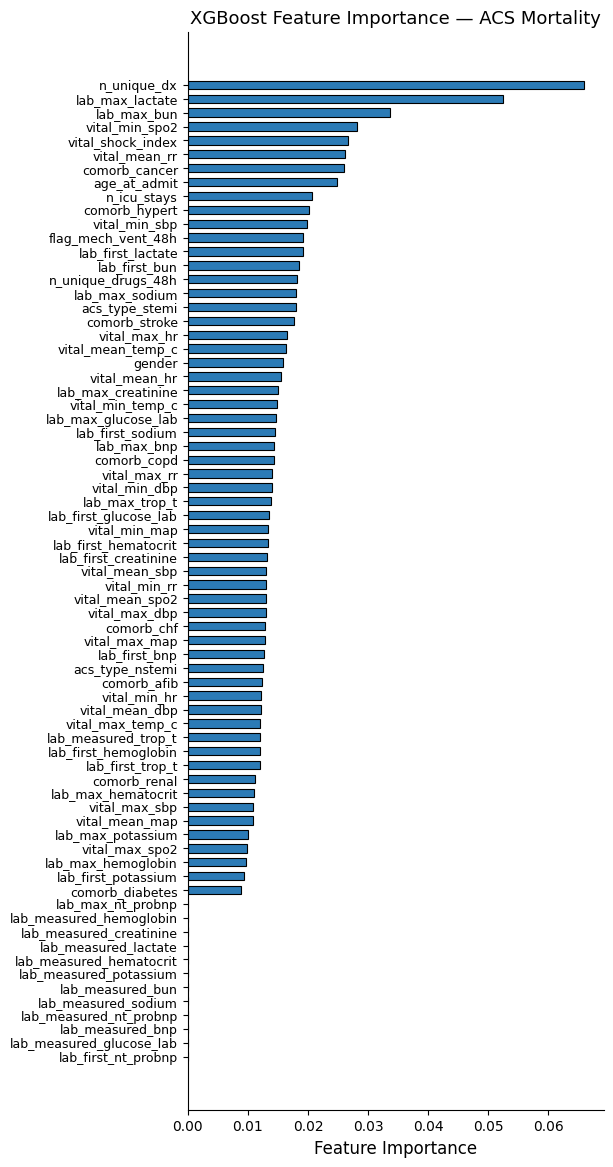

In [ ]:
import matplotlib.pyplot as plt

# 6.1 === Gráfico para ver los datos más importantes que el XGBoost usa ===

fi = pd.DataFrame({
    "feature": COLS_TABULAR,
    "importance": xgb_final.feature_importances_
}).sort_values("importance", ascending=True)

fig, ax = plt.subplots(figsize=(8, 14))

ax.barh(
    fi["feature"],
    fi["importance"],
    color="#2C7BB6",
    edgecolor="black",
    linewidth=0.8,
    height=0.6
)

ax.set_xlabel("Feature Importance", fontsize=12)
ax.set_title("XGBoost Feature Importance — ACS Mortality", fontsize=13)

ax.tick_params(axis='y', labelsize=9)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.subplots_adjust(left=0.38)

plt.savefig(
    "feature_importance_xgboost_acs.pdf",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

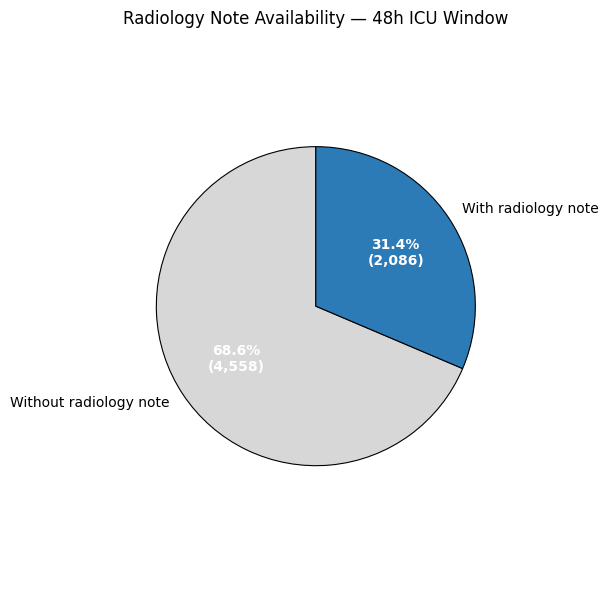

In [ ]:
# 6.2 === Gráfico para ver disponibilidad de notas de radiología en la cohorte ===

n_con_nota = (X_text.str.len() > 0).sum()
n_sin_nota = len(X_text) - n_con_nota

labels = ["Without radiology note", "With radiology note"]
counts = [n_sin_nota, n_con_nota]
colors = ["#D7D7D7", "#2C7BB6"]

fig, ax = plt.subplots(figsize=(6, 6))

wedges, texts, autotexts = ax.pie(
    counts,
    labels=labels,
    colors=colors,
    autopct=lambda p: f"{p:.1f}%\n({int(round(p/100*len(X_text))):,})",
    startangle=90,
    wedgeprops=dict(edgecolor="black", linewidth=0.8),
    textprops=dict(fontsize=10)
)

for autotext in autotexts:
    autotext.set_color("white")
    autotext.set_fontweight("bold")

ax.set_title("Radiology Note Availability — 48h ICU Window", fontsize=12)
ax.axis("equal")

plt.tight_layout()
plt.savefig("note_availability_acs_pie.pdf", bbox_inches="tight", facecolor="white")
plt.show()

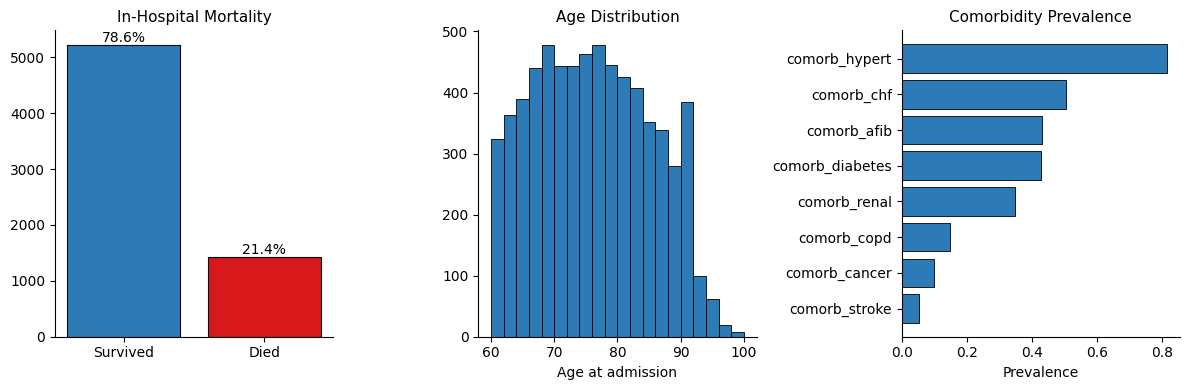

In [ ]:
# 6.3 === Distribución del target y demografía básica ===

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

#Target
counts = y.value_counts().sort_index()

axes[0].bar(
    ["Survived", "Died"],
    counts.values,
    color=["#2C7BB6", "#D7191C"],
    edgecolor="black",
    linewidth=0.8
)

for bar, pct in zip(axes[0].patches, counts / counts.sum() * 100):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{pct:.1f}%",
        ha="center",
        va="bottom",
        fontsize=10
    )

axes[0].set_title("In-Hospital Mortality", fontsize=11)
axes[0].spines[["top", "right"]].set_visible(False)


#Edad
axes[1].hist(
    ds_model["age_at_admit"],
    bins=20,
    color="#2C7BB6",
    edgecolor="black",
    linewidth=0.6
)

axes[1].set_xlabel("Age at admission", fontsize=10)
axes[1].set_title("Age Distribution", fontsize=11)
axes[1].spines[["top", "right"]].set_visible(False)


#Comorbilidades
comorb_cols = list(COMORBIDITY_FLAGS.keys())

comorb_prev = (
    ds_model[comorb_cols]
    .mean()
    .sort_values()
)

axes[2].barh(
    comorb_prev.index,
    comorb_prev.values,
    color="#2C7BB6",
    edgecolor="black",
    linewidth=0.6
)

axes[2].set_xlabel("Prevalence", fontsize=10)
axes[2].set_title("Comorbidity Prevalence", fontsize=11)
axes[2].spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("cohort_descriptives.pdf", bbox_inches="tight", facecolor="white")
plt.show()

In [ ]:
# 6.4 === Datos importantes ===

#Edad
print("Edad:", round(ds_model["age_at_admit"].mean(), 1),
      "±", round(ds_model["age_at_admit"].std(), 1))
print("% hombres:", round((ds_model["gender"] == 1).mean() * 100, 1))
print("% STEMI:", round(ds_model["acs_type_stemi"].mean() * 100, 1))
print("% NSTEMI:", round(ds_model["acs_type_nstemi"].mean() * 100, 1))
print("\nPrevalencia comorbilidades:")
for col in list(COMORBIDITY_FLAGS.keys()):
    print(f"  {col}: {ds_model[col].mean()*100:.1f}%")

Edad: 75.7 ± 9.2
% hombres: 61.6
% STEMI: 18.5
% NSTEMI: 45.4

Prevalencia comorbilidades:
  comorb_chf: 50.3%
  comorb_diabetes: 42.9%
  comorb_renal: 34.7%
  comorb_copd: 14.9%
  comorb_hypert: 81.4%
  comorb_afib: 43.1%
  comorb_stroke: 5.5%
  comorb_cancer: 9.9%


## 7. Test estadístico entre modelos

In [ ]:
# 7.1 === Test estadístico entre modelos los 3 modelos ML y TF-IDF + MLP

from scipy.stats import ttest_rel

auc_rf  = [s["auc"] for s in rf_scores]
auc_cb  = [s["auc"] for s in cb_scores]
auc_xgb = [s["auc"] for s in xgb_scores]
auc_mlp = [s["auc"] for s in mlp_scores]

t1, p1 = ttest_rel(auc_rf, auc_cb)
t2, p2 = ttest_rel(auc_rf, auc_xgb)
t3, p3 = ttest_rel(auc_rf, auc_mlp)
t4, p4 = ttest_rel(auc_cb, auc_xgb)
t5, p5 = ttest_rel(auc_cb, auc_mlp)
t6, p6 = ttest_rel(auc_xgb, auc_mlp)

print(f"RF vs CatBoost  — t={t1:.3f}, p={p1:.4f}")
print(f"RF vs XGBoost   — t={t2:.3f}, p={p2:.4f}")
print(f"RF vs MLP       — t={t3:.3f}, p={p3:.4f}")
print(f"CatBoost vs XGB — t={t4:.3f}, p={p4:.4f}")
print(f"CatBoost vs MLP — t={t5:.3f}, p={p5:.4f}")
print(f"XGBoost vs MLP  — t={t6:.3f}, p={p6:.4f}")

RF vs CatBoost  — t=-2.288, p=0.0841
RF vs XGBoost   — t=-4.143, p=0.0143
RF vs MLP       — t=23.408, p=0.0000
CatBoost vs XGB — t=-1.833, p=0.1407
CatBoost vs MLP — t=32.053, p=0.0000
XGBoost vs MLP  — t=38.166, p=0.0000


# 8. Preparación y verificación pre BioBERT

In [ ]:
# 8.1 === BioBERT - revisión de disponibilidad de notas clínicas ===

#Objetivo:
# - Verificar cuántos pacientes del dataset final tienen texto clínico
#   disponible para BioBERT

#Importante:
# - Esto no es entreno del modelo
# - Primero se revisa si existe texto suficiente y cuál columna se usará

print("Columnas relacionadas con texto/notas:")

text_like_cols = [
    col for col in ds_model.columns
    if any(word in col.lower() for word in ["note", "text", "rad", "report"])
]

print(text_like_cols)

#Seleccionar columna principal de texto
TEXT_COL = "text_note"

assert TEXT_COL in ds_model.columns, f"No existe la columna {TEXT_COL} en ds_model"

#Crear versión limpia del texto
text_series = ds_model[TEXT_COL].fillna("").astype(str)

#Medir disponibilidad
has_text = text_series.str.strip().str.len() > 0

print("\n=== Disponibilidad de texto clínico ===")
print(f"Pacientes totales ds_model        : {len(ds_model)}")
print(f"Pacientes con texto no vacío      : {has_text.sum()}")
print(f"Pacientes sin texto               : {(~has_text).sum()}")
print(f"% con texto                       : {has_text.mean()*100:.2f}%")

print("\nDistribución target global:")
print(ds_model["hospital_expire_flag"].value_counts().sort_index())

print("\nDistribución target en pacientes CON texto:")
print(ds_model.loc[has_text, "hospital_expire_flag"].value_counts().sort_index())

print("\nDistribución target en pacientes SIN texto:")
print(ds_model.loc[~has_text, "hospital_expire_flag"].value_counts().sort_index())

print("\nEjemplo de texto:")
display(
    ds_model.loc[has_text, ["subject_id", "hospital_expire_flag", TEXT_COL]]
    .head(3)
)

Columnas relacionadas con texto/notas:
['text_note']

=== Disponibilidad de texto clínico ===
Pacientes totales ds_model        : 6644
Pacientes con texto no vacío      : 2086
Pacientes sin texto               : 4558
% con texto                       : 31.40%

Distribución target global:
hospital_expire_flag
0    5222
1    1422
Name: count, dtype: int64

Distribución target en pacientes CON texto:
hospital_expire_flag
0    1641
1     445
Name: count, dtype: int64

Distribución target en pacientes SIN texto:
hospital_expire_flag
0    3581
1     977
Name: count, dtype: int64

Ejemplo de texto:


,subject_id,hospital_expire_flag,text_note
1,10002495,0,EXAMINATION: CHEST (PORTABLE AP)\n\nINDICATIO...
2,10004422,0,"INDICATION: ___ man, status post CABG.\n\nCOM..."
6,10011398,0,"AP CHEST, 12:35 P.M. ON ___.\n\nHISTORY: Card..."


In [ ]:
# 8.2 === BioBERT-LoRA multimodal - revisión de notas clínicas ===

#Objetivo:
# - Verificar cuántos pacientes del dataset final pareado tienen texto clínico
#   disponible para el modelo multimodal

#Importante:
# - No se eliminan pacientes sin nota
# - El modelo usará has_text para que el gate α aprenda cuándo confiar en texto
#   y cuándo apoyarse más en las variables estructuradas

print("Columnas relacionadas con texto/notas:")

text_like_cols = [
    col for col in ds_model.columns
    if any(word in col.lower() for word in ["note", "text", "rad", "report"])
]

print(text_like_cols)

#Columna de texto principal
TEXT_COL = "text_note"
TARGET_COL = "hospital_expire_flag"

assert TEXT_COL in ds_model.columns, f"No existe la columna {TEXT_COL} en ds_model"
assert TARGET_COL in ds_model.columns, f"No existe la columna {TARGET_COL} en ds_model"

#Limpiar texto solo para diagnóstico
text_series = ds_model[TEXT_COL].fillna("").astype(str).str.strip()
has_text = (text_series.str.len() > 0).astype(int)

print("\n=== Disponibilidad de texto clínico ===")
print(f"Pacientes totales ds_model   : {len(ds_model)}")
print(f"Pacientes con texto no vacío : {has_text.sum()}")
print(f"Pacientes sin texto          : {(1 - has_text).sum()}")
print(f"% con texto                  : {has_text.mean()*100:.2f}%")

print("\nDistribución target global:")
print(ds_model[TARGET_COL].value_counts().sort_index())

print("\nDistribución target según disponibilidad de texto:")
print(
    pd.crosstab(
        ds_model[TARGET_COL],
        has_text,
        rownames=["target"],
        colnames=["has_text"]
    )
)

print("\nEjemplo de texto con nota:")
idx_text = has_text[has_text == 1].index[0]
print(text_series.loc[idx_text][:1000])

Columnas relacionadas con texto/notas:
['text_note']

=== Disponibilidad de texto clínico ===
Pacientes totales ds_model   : 6644
Pacientes con texto no vacío : 2086
Pacientes sin texto          : 4558
% con texto                  : 31.40%

Distribución target global:
hospital_expire_flag
0    5222
1    1422
Name: count, dtype: int64

Distribución target según disponibilidad de texto:
has_text     0     1
target              
0         3581  1641
1          977   445

Ejemplo de texto con nota:
EXAMINATION:  CHEST (PORTABLE AP)

INDICATION:  ___ year old man with STEMI w/ dyspnea, rhonchi, crackles, and
hypoxia  // e/o consolidation for possible PNA

COMPARISON:  None available

IMPRESSION: 

Cardiomediastinal contours are normal.  Pulmonary vascular congestion is
accompanied by asymmetrically distributed airspace opacities in the right
perihilar and bibasilar regions, right greater than left.  This could
potentially represent asymmetrical edema, multifocal aspiration, and/or
developin

In [ ]:
# 8.3 === Definir columna de texto ===

#Esta es la columna textual real encontrada en ds_model
#Se usará como entrada para BioBERT

TEXT_COL = "text_note"

assert TEXT_COL in ds_model.columns, f"No existe la columna {TEXT_COL} en ds_model"

print("Columna textual seleccionada:", TEXT_COL)
print("Existe en ds_model:", TEXT_COL in ds_model.columns)

Columna textual seleccionada: text_note
Existe en ds_model: True


In [ ]:
# 8.4 === Disponibilidad real de texto clínico ===

#Objetivo:
# - Medir disponibilidad real de texto clínico sin modificar ds_model

#Importante:
# - No agregamos columnas auxiliares a ds_model para evitar que entren
#   accidentalmente como predictores tabulares.

text_clean_check = (
    ds_model[TEXT_COL]
    .fillna("")
    .astype(str)
    .str.strip()
)

has_text_check = text_clean_check.str.len() > 0
n_chars_text_check = text_clean_check.str.len()

n_total = len(ds_model)
n_with_text = has_text_check.sum()
n_without_text = n_total - n_with_text

print("Total pacientes:", n_total)
print("Pacientes con nota clínica:", n_with_text)
print("Pacientes sin nota clínica:", n_without_text)

print("\nPorcentaje con nota clínica:")
print(round(n_with_text / n_total * 100, 2), "%")

print("\nPorcentaje sin nota clínica:")
print(round(n_without_text / n_total * 100, 2), "%")

print("\nLongitud de notas en pacientes con texto:")
print(n_chars_text_check[has_text_check].describe())

Total pacientes: 6644
Pacientes con nota clínica: 2086
Pacientes sin nota clínica: 4558

Porcentaje con nota clínica:
31.4 %

Porcentaje sin nota clínica:
68.6 %

Longitud de notas en pacientes con texto:
count    2086.000000
mean      820.761745
std       660.680517
min        96.000000
25%       500.250000
50%       648.000000
75%       878.000000
max      6393.000000
Name: text_note, dtype: float64


In [ ]:
# 8.5 === Disponibilidad de texto según target ===

#Objetivo:
# - Revisar si la disponibilidad de texto está balanceada entre sobrevivientes
#   y fallecidos

#Importante:
# - No se modifica ds_model
# - Se usa directamente hospital_expire_flag como target

TARGET_COL = "hospital_expire_flag"

assert TARGET_COL in ds_model.columns, f"No existe la columna {TARGET_COL} en ds_model"

#Texto limpio temporal
text_clean_check = (
    ds_model[TEXT_COL]
    .fillna("")
    .astype(str)
    .str.strip()
)

#Indicador temporal de texto disponible
has_text_check = text_clean_check.str.len() > 0

#Tabla temporal solo para diagnóstico
temp_text_balance = pd.DataFrame({
    "target": ds_model[TARGET_COL].astype(int),
    "has_text": has_text_check.astype(int)
})

text_by_target = (
    temp_text_balance
    .groupby("target")["has_text"]
    .agg(["count", "sum"])
    .rename(columns={
        "count": "total_pacientes",
        "sum": "pacientes_con_texto"
    })
)

text_by_target["pacientes_sin_texto"] = (
    text_by_target["total_pacientes"] - text_by_target["pacientes_con_texto"]
)

text_by_target["pct_con_texto"] = (
    text_by_target["pacientes_con_texto"] / text_by_target["total_pacientes"] * 100
).round(2)

text_by_target["pct_sin_texto"] = (
    text_by_target["pacientes_sin_texto"] / text_by_target["total_pacientes"] * 100
).round(2)

text_by_target

,total_pacientes,pacientes_con_texto,pacientes_sin_texto,pct_con_texto,pct_sin_texto
target,,,,,
0,5222,1641,3581,31.42,68.58
1,1422,445,977,31.29,68.71


In [ ]:
# 8.6 === Verificar target para BioBERT-LoRA ===

#Objetivo:
# - Confirmar que el target del modelo multimodal tiene el mismo tamaño que
#   ds_model y está balanceado

TARGET_COL = "hospital_expire_flag"

assert TARGET_COL in ds_model.columns, f"No existe la columna {TARGET_COL} en ds_model"

y_bert = ds_model[TARGET_COL].astype(int)

print("Tamaño de ds_model:", len(ds_model))
print("Tamaño de y_bert:", len(y_bert))

print("\nDistribución de y_bert:")
print(y_bert.value_counts().sort_index())

assert len(ds_model) == len(y_bert), "ds_model e y_bert tienen distinto tamaño"
assert y_bert.isin([0, 1]).all(), "y_bert tiene valores distintos de 0/1"

Tamaño de ds_model: 6644
Tamaño de y_bert: 6644

Distribución de y_bert:
hospital_expire_flag
0    5222
1    1422
Name: count, dtype: int64


In [ ]:
# 8.7 === Longitud de notas clínicas disponibles por clase ===

#Objetivo:
# - Revisar si la longitud de las notas clínicas difiere mucho entre clases

#Importante:
# - No modificamos ds_model
# - No usamos la variable global y
# - Usamos directamente hospital_expire_flag

TARGET_COL = "hospital_expire_flag"

assert TEXT_COL in ds_model.columns, f"No existe la columna {TEXT_COL} en ds_model"
assert TARGET_COL in ds_model.columns, f"No existe la columna {TARGET_COL} en ds_model"

#Texto limpio temporal
text_clean_check = (
    ds_model[TEXT_COL]
    .fillna("")
    .astype(str)
    .str.strip()
)

#Variables temporales
has_text_check = text_clean_check.str.len() > 0
n_chars_text_check = text_clean_check.str.len()

#DataFrame temporal solo para diagnóstico
temp_text_length = pd.DataFrame({
    "target": ds_model[TARGET_COL].astype(int),
    "has_text": has_text_check,
    "n_chars_text": n_chars_text_check
})

#Estadísticas de longitud solo en pacientes con texto
text_length_stats = (
    temp_text_length[temp_text_length["has_text"]]
    .groupby("target")["n_chars_text"]
    .describe()
)

text_length_stats

,count,mean,std,min,25%,50%,75%,max
target,,,,,,,,
0,1641.0,812.959781,642.015822,96.0,502.0,648.0,865.0,6393.0
1,445.0,849.532584,725.422159,108.0,490.0,645.0,931.0,5568.0


In [ ]:
# 8.8 === Notas clínicas muy cortas ===

#Objetivo:
# - Revisar cuántos pacientes tienen notas clínicas demasiado cortas

#Importante:
# - No modificamos ds_model
# - No usamos y global
# - Esto es solo diagnóstico, no filtro obligatorio

SHORT_TEXT_THRESHOLD = 100
TARGET_COL = "hospital_expire_flag"

assert TEXT_COL in ds_model.columns, f"No existe la columna {TEXT_COL} en ds_model"
assert TARGET_COL in ds_model.columns, f"No existe la columna {TARGET_COL} en ds_model"

#Texto limpio temporal
text_clean_check = (
    ds_model[TEXT_COL]
    .fillna("")
    .astype(str)
    .str.strip()
)

#Variables temporales
has_text_check = text_clean_check.str.len() > 0
n_chars_text_check = text_clean_check.str.len()

short_text_check = (
    has_text_check &
    (n_chars_text_check < SHORT_TEXT_THRESHOLD)
)

#DataFrame temporal solo para diagnóstico
temp_short_text = pd.DataFrame({
    "target": ds_model[TARGET_COL].astype(int),
    "has_text": has_text_check.astype(int),
    "short_text": short_text_check.astype(int)
})

short_text_summary = (
    temp_short_text
    .groupby("target")["short_text"]
    .agg(["count", "sum"])
    .rename(columns={
        "count": "total_pacientes",
        "sum": "pacientes_con_texto_corto"
    })
)

short_text_summary["pct_texto_corto"] = (
    short_text_summary["pacientes_con_texto_corto"] /
    short_text_summary["total_pacientes"] * 100
).round(2)

short_text_summary

,total_pacientes,pacientes_con_texto_corto,pct_texto_corto
target,,,
0,5222,1,0.02
1,1422,0,0.00


## 9. BioBERT

In [ ]:
# 9.1 === Preparación de texto clínico para modelo multimodal ===

#Objetivo:
# - Preparar la columna textual para BioBERT-LoRA multimodal

#Decisión metodológica:
# - No modificamos ds_model directamente
# - Creamos ds_mm como copia de trabajo para el modelo multimodal

#Variables creadas:
# - text_clean: texto limpio original
# - has_text: 1 si el paciente tiene nota real, 0 si no
# - n_chars_text: longitud del texto clínico
# - text_for_bert: texto que entra al tokenizer

#Importante:
# - Los pacientes sin nota NO se eliminan
# - Para ellos se usa un placeholder textual, pero luego el gate α usará
#   has_text para reducir o anular el peso de la rama textual

TEXT_COL = "text_note"
TARGET_COL = "hospital_expire_flag"

assert TEXT_COL in ds_model.columns, f"No existe la columna {TEXT_COL} en ds_model"
assert TARGET_COL in ds_model.columns, f"No existe la columna {TARGET_COL} en ds_model"

#Copia exclusiva para el modelo multimodal
ds_mm = ds_model.copy()

# Crear texto limpio
ds_mm["text_clean"] = (
    ds_mm[TEXT_COL]
    .fillna("")
    .astype(str)
    .str.strip()
)

#Indicador de texto disponible
ds_mm["has_text"] = (ds_mm["text_clean"].str.len() > 0).astype(int)

#Largo del texto
ds_mm["n_chars_text"] = ds_mm["text_clean"].str.len()

#Texto para BioClinicalBERT
#Para pacientes sin nota usamos placeholder para evitar errores del tokenizer.
ds_mm["text_for_bert"] = ds_mm["text_clean"].where(
    ds_mm["has_text"] == 1,
    "[NO CLINICAL NOTE AVAILABLE]"
)

print("Total pacientes:", len(ds_mm))
print("Con texto:", ds_mm["has_text"].sum())
print("Sin texto:", (1 - ds_mm["has_text"]).sum())

print("\nPorcentaje con texto:")
print(round(ds_mm["has_text"].mean() * 100, 2), "%")

print("\nDistribución target:")
print(ds_mm[TARGET_COL].value_counts().sort_index())

print("\nDisponibilidad de texto según target:")
print(
    pd.crosstab(
        ds_mm[TARGET_COL].astype(int),
        ds_mm["has_text"],
        rownames=["target"],
        colnames=["has_text"]
    )
)

print("\nEjemplo text_for_bert:")
print(ds_mm["text_for_bert"].iloc[0][:500])

Total pacientes: 6644
Con texto: 2086
Sin texto: 4558

Porcentaje con texto:
31.4 %

Distribución target:
hospital_expire_flag
0    5222
1    1422
Name: count, dtype: int64

Disponibilidad de texto según target:
has_text     0     1
target              
0         3581  1641
1          977   445

Ejemplo text_for_bert:
[NO CLINICAL NOTE AVAILABLE]


In [ ]:
# 9.2 === Preparación de variables tabulares para BioBERT-LoRA ===

#Objetivo:
# - Construir X_tab_bert usando exactamente las mismas variables tabulares
#   definidas en COLS_TABULAR

#Decisión metodológica:
# - No se seleccionan columnas automáticamente
# - Se usan COLS_TABULAR para evitar incluir accidentalmente:
#   * identificadores
#   * target
#   * texto
#   * variables auxiliares
#   * procedimientos sin timestamp

#Importante:
# - La imputación y el escalado no se hacen aquí
# - Se harán dentro de cada fold para evitar leakage

assert "COLS_TABULAR" in globals(), "COLS_TABULAR no está definido. Ejecuta primero el bloque 4.3."
assert "ds_mm" in globals(), "ds_mm no está definido. Ejecuta primero el bloque de preparación multimodal."

#Verificar que todas las columnas tabulares existen en ds_mm
missing_tab_cols = [col for col in COLS_TABULAR if col not in ds_mm.columns]
assert not missing_tab_cols, f"Columnas de COLS_TABULAR faltantes en ds_mm: {missing_tab_cols}"

#Construir matriz tabular para BioClinicalBERT-LoRA
X_tab_bert = ds_mm[COLS_TABULAR].copy()

#gender ya viene como 0/1 desde el pipeline
#solo convertir si todavía es texto
if "gender" in X_tab_bert.columns:
    if X_tab_bert["gender"].dtype == object:
        X_tab_bert["gender"] = X_tab_bert["gender"].replace({"M": 1, "F": 0})
    X_tab_bert["gender"] = pd.to_numeric(X_tab_bert["gender"], errors="coerce")

#Asegurar que todo sea numérico
for col in X_tab_bert.columns:
    X_tab_bert[col] = pd.to_numeric(X_tab_bert[col], errors="coerce")

#Verificación
print("gender dtype :", X_tab_bert["gender"].dtype)
print("gender NaN   :", X_tab_bert["gender"].isna().sum())
print("gender únicos:", X_tab_bert["gender"].unique())

assert X_tab_bert["gender"].isna().sum() == 0, \
    "gender tiene NaN en X_tab_bert — revisar pipeline"

print("Número de columnas tabulares para BioClinicalBERT-LoRA:", X_tab_bert.shape[1])
print("Shape X_tab_bert:", X_tab_bert.shape)

print("\nColumnas tabulares usadas:")
print(list(X_tab_bert.columns))

print("\nValores faltantes totales en X_tab_bert:")
print(X_tab_bert.isna().sum().sum())

gender dtype : int64
gender NaN   : 0
gender únicos: [0 1]
Número de columnas tabulares para BioClinicalBERT-LoRA: 71
Shape X_tab_bert: (6644, 71)

Columnas tabulares usadas:
['gender', 'age_at_admit', 'n_icu_stays', 'n_unique_dx', 'n_unique_drugs_48h', 'acs_type_stemi', 'acs_type_nstemi', 'comorb_chf', 'comorb_diabetes', 'comorb_renal', 'comorb_copd', 'comorb_hypert', 'comorb_afib', 'comorb_stroke', 'comorb_cancer', 'lab_first_bnp', 'lab_first_bun', 'lab_first_creatinine', 'lab_first_glucose_lab', 'lab_first_hematocrit', 'lab_first_hemoglobin', 'lab_first_lactate', 'lab_first_nt_probnp', 'lab_first_potassium', 'lab_first_sodium', 'lab_first_trop_t', 'lab_max_bnp', 'lab_max_bun', 'lab_max_creatinine', 'lab_max_glucose_lab', 'lab_max_hematocrit', 'lab_max_hemoglobin', 'lab_max_lactate', 'lab_max_nt_probnp', 'lab_max_potassium', 'lab_max_sodium', 'lab_max_trop_t', 'lab_measured_trop_t', 'lab_measured_creatinine', 'lab_measured_hemoglobin', 'lab_measured_lactate', 'lab_measured_glucose_la

In [ ]:
# 9.3 === Preparar entradas finales para BioBERT-LoRA ===

#Objetivo:
# - Dejar listas las entradas multimodales:
#   * X_tab_df: variables estructuradas sin imputar ni escalar
#   *  X_text_bert: texto para BioBERT
#   * has_text_bert: indicador de disponibilidad de nota
#   * n_chars_text_bert: longitud de nota
#   * y_bert: target

#Importante:
# - No se aplica fillna(0)
# - No se aplica StandardScaler aquí
# - La imputación por mediana y el escalado se harán dentro de cada fold

assert "ds_mm" in globals(), "ds_mm no está definido. Ejecuta primero el bloque 5.12."
assert "X_tab_bert" in globals(), "X_tab_bert no está definido. Ejecuta primero el bloque 5.13."

TARGET_COL = "hospital_expire_flag"

#1) Tabular
X_tab_df = X_tab_bert.copy()

#Reemplazar infinitos por NaN
X_tab_df = X_tab_df.replace([np.inf, -np.inf], np.nan)

#2) Texto
X_text_bert = ds_mm["text_for_bert"].astype(str).copy()

#3) Gate / informatividad
has_text_bert = ds_mm["has_text"].astype(int).copy()
n_chars_text_bert = ds_mm["n_chars_text"].astype(float).copy()

#4) Target
y_bert = ds_mm[TARGET_COL].astype(int).copy()

#5) Validaciones
assert len(X_tab_df) == len(X_text_bert) == len(has_text_bert) == len(n_chars_text_bert) == len(y_bert), \
    "Las entradas multimodales tienen distinto tamaño"

assert y_bert.isin([0, 1]).all(), "y_bert tiene valores distintos de 0/1"
assert has_text_bert.isin([0, 1]).all(), "has_text_bert tiene valores distintos de 0/1"

print("=== Entradas BioClinicalBERT-LoRA multimodal ===")
print("Shape X_tab_df:", X_tab_df.shape)
print("Shape X_text_bert:", X_text_bert.shape)
print("Shape has_text_bert:", has_text_bert.shape)
print("Shape n_chars_text_bert:", n_chars_text_bert.shape)
print("Shape y_bert:", y_bert.shape)

print("\nPacientes con texto:", has_text_bert.sum())
print("Pacientes sin texto:", (1 - has_text_bert).sum())

print("\nValores faltantes en X_tab_df:")
print(X_tab_df.isna().sum().sum())

print("\nDistribución target:")
print(y_bert.value_counts().sort_index())

=== Entradas BioClinicalBERT-LoRA multimodal ===
Shape X_tab_df: (6644, 71)
Shape X_text_bert: (6644,)
Shape has_text_bert: (6644,)
Shape n_chars_text_bert: (6644,)
Shape y_bert: (6644,)

Pacientes con texto: 2086
Pacientes sin texto: 4558

Valores faltantes en X_tab_df:
165303

Distribución target:
hospital_expire_flag
0    5222
1    1422
Name: count, dtype: int64


In [ ]:
# 9.4 === Features de informatividad textual para gate α ===

#Objetivo:
# - Crear variables auxiliares para que el gate α estime cuánta información
#   textual útil tiene cada paciente

#Estas variables NO reemplazan al texto de BioBERT
#Solo ayudan al gate a decidir cuánto peso darle a la rama textual

#Variables:
# - has_text: indica si existe nota real
# - log_n_chars_text: longitud logarítmica de la nota
# - n_clinical_terms: cantidad de términos clínicos simples encontrados
# - n_words: número aproximado de palabras
# - has_negation: presencia de negaciones o frases normales

assert "ds_mm" in globals(), "ds_mm no está definido. Ejecuta primero el bloque 5.12."

CLINICAL_TERMS = [
    "cardiomegaly", "cardiomegalia", "effusion", "derrame",
    "edema", "pneumonia", "pneumothorax", "consolidation",
    "opacity", "infiltrate", "pleural", "atelectasis",
    "enlarged", "bilateral", "severe", "moderate"
]

#Texto limpio desde ds_mm
text_lower = ds_mm["text_clean"].fillna("").astype(str).str.lower()

#Conteo de términos clínicos
n_clinical_terms = sum(
    text_lower.str.contains(term, regex=False).astype(int)
    for term in CLINICAL_TERMS
)

gate_features_df = pd.DataFrame({
    "has_text": ds_mm["has_text"].astype(int),
    "log_n_chars_text": np.log1p(ds_mm["n_chars_text"].astype(float)),
    "n_clinical_terms": n_clinical_terms,
    "n_words": text_lower.str.split().str.len().fillna(0),
    "has_negation": text_lower.str.contains(
        r"\bno\b|\bnormal\b|\bnegative\b|\bsin hallazgo\b|\bwithin normal\b",
        regex=True
    ).astype(int),
})

#Para pacientes sin texto, las features de informatividad deben quedar en 0,
#excepto has_text, que ya es 0.
cols_info = [
    "log_n_chars_text",
    "n_clinical_terms",
    "n_words",
    "has_negation"
]

gate_features_df.loc[gate_features_df["has_text"] == 0, cols_info] = 0

#Relleno seguro para variables auxiliares del gate
gate_features_df = gate_features_df.fillna(0)

#Validaciones
assert len(gate_features_df) == len(ds_mm), "gate_features_df y ds_mm tienen distinto tamaño"
assert gate_features_df["has_text"].isin([0, 1]).all(), "has_text tiene valores distintos de 0/1"

print("Shape gate_features_df:", gate_features_df.shape)
print("\nResumen gate_features_df:")
display(gate_features_df.describe().round(2))

print("\nPromedio de features del gate según has_text:")
display(gate_features_df.groupby("has_text").mean().round(2))

Shape gate_features_df: (6644, 5)

Resumen gate_features_df:


,has_text,log_n_chars_text,n_clinical_terms,n_words,has_negation
count,6644.00,6644.00,6644.00,6644.00,6644.00
mean,0.31,2.05,1.22,37.56,0.26
std,0.46,3.05,2.20,77.68,0.44
min,0.00,0.00,0.00,0.00,0.00
25%,0.00,0.00,0.00,0.00,0.00
50%,0.00,0.00,0.00,0.00,0.00
75%,1.00,6.15,2.00,68.00,1.00
max,1.00,8.76,12.00,930.00,1.00



Promedio de features del gate según has_text:


,log_n_chars_text,n_clinical_terms,n_words,has_negation
has_text,,,,
0,0.00,0.00,0.00,0.00
1,6.54,3.89,119.63,0.84


In [ ]:
# 9.5 === Instalación de librerías para BioBERT-LoRA ===

#Objetivo:
# - Instalar librerías necesarias para:
#   * BioBERT desde transformers
#   * LoRA mediante PEFT
#   * entrenamiento con PyTorch

#Nota:
# - torchao puede generar conflictos de compatibilidad en algunos entornos
#   de Colab, por eso se desinstala si está presente

!pip uninstall -y torchao
!pip install -q -U transformers peft accelerate

Found existing installation: torchao 0.10.0
Uninstalling torchao-0.10.0:
  Successfully uninstalled torchao-0.10.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 106.9 MB/s eta 0:00:00


In [ ]:
# 9.6 === Imports para modelo multimodal BioBERT-LoRA ===

#Imports necesarios para:
# - Dataset/DataLoader en PyTorch
# - BioBERT desde transformers
# - LoRA mediante PEFT
# - imputación/escalado tabular por fold
# - métricas y control de memoria

import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from transformers import AutoTokenizer, AutoModel
from peft import LoraConfig, get_peft_model, TaskType

from tqdm.auto import tqdm

In [ ]:
# 9.7 === Verificar dispositivo de entrenamiento ===

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from transformers import AutoTokenizer, AutoModel
from peft import LoraConfig, get_peft_model, TaskType

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    recall_score,
    precision_score,
    confusion_matrix
)

from tqdm.auto import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Dispositivo:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Dispositivo: cuda
GPU: Tesla T4


In [ ]:
# 9.8 === Dataset multimodal para BioBERT-LoRA + tabular + gate ===

#Objetivo:
# - Crear un Dataset de PyTorch que entregue, para cada paciente:
#   * tokens del texto clínico
#   * variables tabulares
#   * variables auxiliares del gate
#   * máscara has_text
#   * target

class MultimodalMIMICDataset(Dataset):
    def __init__(
        self,
        texts,
        X_tab,
        X_gate,
        y,
        has_text,
        tokenizer,
        max_length=384
    ):
        #Texto
        self.texts = pd.Series(texts).reset_index(drop=True).astype(str)

        #Variables tabulares y del gate
        self.X_tab = torch.tensor(np.asarray(X_tab), dtype=torch.float32)
        self.X_gate = torch.tensor(np.asarray(X_gate), dtype=torch.float32)

        #Target
        self.y = torch.tensor(
            np.asarray(y),
            dtype=torch.float32
        )

        #Indicador de disponibilidad de texto
        self.has_text = torch.tensor(
            np.asarray(has_text).astype(int),
            dtype=torch.float32
        )

        self.tokenizer = tokenizer
        self.max_length = max_length

        #Validación de tamaños
        assert len(self.texts) == len(self.X_tab) == len(self.X_gate) == len(self.y) == len(self.has_text), \
            "Los componentes del Dataset tienen distinto tamaño"

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        text = str(self.texts.iloc[idx])

        encoded = self.tokenizer(
            text,
            padding="max_length",
            truncation=True,
            max_length=self.max_length,
            return_tensors="pt"
        )

        item = {
            "input_ids": encoded["input_ids"].squeeze(0),
            "attention_mask": encoded["attention_mask"].squeeze(0),
            "x_tab": self.X_tab[idx],
            "x_gate": self.X_gate[idx],
            "has_text": self.has_text[idx],
            "labels": self.y[idx]
        }

        return item

In [ ]:
# 9.9 === Tokenizer BioBERT ===

#Objetivo:
# - Cargar el tokenizer correspondiente a BioBERT

from transformers import BertTokenizer

MODEL_NAME = "dmis-lab/biobert-base-cased-v1.1"
TOKENIZER_NAME = "google-bert/bert-base-cased"

tokenizer = BertTokenizer.from_pretrained(
    TOKENIZER_NAME,
    do_lower_case=False
)

print("Modelo:", MODEL_NAME)
print("Tokenizer:", TOKENIZER_NAME)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")


tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/213k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/436k [00:00<?, ?B/s]

Modelo: dmis-lab/biobert-base-cased-v1.1
Tokenizer: google-bert/bert-base-cased


In [ ]:
# 9.10 === Prueba rápida del Dataset multimodal ===

#Objetivo:
# - Verificar que MultimodalMIMICDataset entrega correctamente:
#   * input_ids
#   * attention_mask
#   * x_tab
#   * x_gate
#   * has_text
#   * labels

#Importante:
# - Este escalado es SOLO para probar shapes
# - No se usa para entrenamiento final
# - En el 5-Fold final, imputación y escalado se harán dentro de cada fold

assert "ds_mm" in globals(), "ds_mm no está definido."
assert "X_tab_df" in globals(), "X_tab_df no está definido."
assert "gate_features_df" in globals(), "gate_features_df no está definido."
assert "y_bert" in globals(), "y_bert no está definido."
assert "tokenizer" in globals(), "tokenizer no está definido."

#Imputación/escalado temporal solo para verificar el Dataset
tmp_tab_imputer = SimpleImputer(strategy="median")
tmp_tab_scaler = StandardScaler()
tmp_gate_scaler = StandardScaler()

X_tab_tmp = tmp_tab_imputer.fit_transform(X_tab_df)
X_tab_scaled_tmp = tmp_tab_scaler.fit_transform(X_tab_tmp)

X_gate_scaled_tmp = tmp_gate_scaler.fit_transform(gate_features_df)

test_dataset = MultimodalMIMICDataset(
    texts=ds_mm["text_for_bert"],
    X_tab=X_tab_scaled_tmp,
    X_gate=X_gate_scaled_tmp,
    y=y_bert,
    has_text=ds_mm["has_text"],
    tokenizer=tokenizer,
    max_length=384
)

sample = test_dataset[0]

print("input_ids:", sample["input_ids"].shape)
print("attention_mask:", sample["attention_mask"].shape)
print("x_tab:", sample["x_tab"].shape)
print("x_gate:", sample["x_gate"].shape)
print("has_text:", sample["has_text"])
print("label:", sample["labels"])

print("\nTamaño dataset de prueba:", len(test_dataset))

input_ids: torch.Size([384])
attention_mask: torch.Size([384])
x_tab: torch.Size([71])
x_gate: torch.Size([5])
has_text: tensor(0.)
label: tensor(0.)

Tamaño dataset de prueba: 6644


In [ ]:
# 9.11 === Modelo multimodal BioBERT-LoRA + MLP tabular + gate α ===

#Arquitectura:
# - Texto clínico -> BioBERT-LoRA -> h_text
# - Variables tabulares -> MLP tabular -> h_tab
# - h_text + h_tab + señales gate -> α

#Fusión:
# - h_fused = α * h_text + (1 - α) * h_tab

#Clasificador final:
# - h_fused -> logit de mortalidad

#Interpretación:
# - Si has_text = 1, el gate puede asignar peso al texto
# - Si has_text = 0, forzamos α = 0 y el modelo usa solo la rama tabular

from transformers import BertConfig, BertModel


class BioBERTLoRAGatedFusion(nn.Module):
    def __init__(
        self,
        model_name,
        n_tab_features,
        n_gate_features,
        hidden_dim=128,
        dropout=0.3
    ):
        super().__init__()

        #BioBERT utiliza la arquitectura de BERT-base-cased
        #Se carga una configuración BERT explícita porque el config.json
        #del checkpoint BioBERT no contiene la clave model_type
        bert_config = BertConfig.from_pretrained(
            "google-bert/bert-base-cased"
        )

        #Encoder textual con los pesos preentrenados de BioBERT
        self.bert = BertModel.from_pretrained(
            model_name,
            config=bert_config
        )

        #Configuración LoRA
        #Entrenamos adaptadores LoRA sobre las capas de atención
        #Esto evita fine-tunear todos los pesos de BioBERT
        lora_config = LoraConfig(
            task_type=TaskType.FEATURE_EXTRACTION,
            r=8,
            lora_alpha=16,
            lora_dropout=0.1,
            target_modules=["query", "value"]
        )

        self.bert = get_peft_model(self.bert, lora_config)

        bert_hidden_size = self.bert.config.hidden_size  #Normalmente 768

        #Proyección textual
        #Convierte el embedding [CLS] de BioBERT a hidden_dim
        self.text_projection = nn.Sequential(
            nn.Linear(bert_hidden_size, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout)
        )

        #Rama tabular MLP
        #Convierte las variables estructuradas a hidden_dim
        self.tabular_mlp = nn.Sequential(
            nn.Linear(n_tab_features, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout)
        )

        #Gate de informatividad α
        #Recibe h_text + h_tab + señales auxiliares de informatividad textual
        #Devuelve un valor entre 0 y 1
        self.gate = nn.Sequential(
            nn.Linear(hidden_dim * 2 + n_gate_features, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1),
            nn.Sigmoid()
        )

        #Clasificador final
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1)
        )

    def forward(
        self,
        input_ids,
        attention_mask,
        x_tab,
        x_gate,
        has_text
    ):
        #Asegurar forma [batch, 1] para has_text
        if has_text.dim() == 1:
            has_text = has_text.unsqueeze(1)

        #Rama textual
        bert_outputs = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        #Representación [CLS]
        cls_embedding = bert_outputs.last_hidden_state[:, 0, :]

        h_text = self.text_projection(cls_embedding)

        #Rama tabular
        h_tab = self.tabular_mlp(x_tab)

        #Gate α
        gate_input = torch.cat([h_text, h_tab, x_gate], dim=1)
        alpha_raw = self.gate(gate_input)

        #Forzar α = 0 cuando no hay texto clínico real
        alpha = alpha_raw * has_text

        #Fusión multimodal
        h_fused = alpha * h_text + (1 - alpha) * h_tab

        #Clasificación final
        logits = self.classifier(h_fused).squeeze(1)

        return logits, alpha.squeeze(1)

In [ ]:
# 9.12 === Instanciar modelo y revisar parámetros entrenables ===

#Objetivo:
# - Verificar que la arquitectura se puede crear correctamente y que LoRA
#   deja solo una fracción pequeña de BioBERT como entrenable

#Importante:
# - Esta instancia es solo de prueba
# - En el entrenamiento 5-Fold se creará un modelo nuevo dentro de cada fold

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

model = BioBERTLoRAGatedFusion(
    model_name=MODEL_NAME,
    n_tab_features=X_tab_df.shape[1],
    n_gate_features=gate_features_df.shape[1],
    hidden_dim=128,
    dropout=0.3
).to(device)

print("Modelo instanciado correctamente.")
print("\nParámetros entrenables en BioClinicalBERT-LoRA:")
model.bert.print_trainable_parameters()

#Liberar esta instancia de prueba para no ocupar memoria antes del 5-Fold
del model
gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/313 [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  436MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: dmis-lab/biobert-base-cased-v1.1
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors: reconstructing file:   0%|          |  0.00B /  436MB            

model.safetensors: downloading bytes:           |  0.00B            

Modelo instanciado correctamente.

Parámetros entrenables en BioClinicalBERT-LoRA:
trainable params: 294,912 || all params: 108,605,184 || trainable%: 0.2715


In [ ]:
# 9.13 === Prueba forward del modelo multimodal ===

#Objetivo:
# - Verificar que el modelo recibe correctamente:
#   * input_ids
#   * attention_mask
#   * x_tab
#   * x_gate
#   * has_text

#Va a devolver:
# - logits
# - alpha

#Importante:
#Esta prueba NO entrena el modelo
#Solo verifica que la arquitectura funciona

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

#Crear modelo temporal para prueba forward
model_test = BioBERTLoRAGatedFusion(
    model_name=MODEL_NAME,
    n_tab_features=X_tab_df.shape[1],
    n_gate_features=gate_features_df.shape[1],
    hidden_dim=128,
    dropout=0.3
).to(device)

test_loader = DataLoader(
    test_dataset,
    batch_size=4,
    shuffle=False
)

batch = next(iter(test_loader))

input_ids = batch["input_ids"].to(device)
attention_mask = batch["attention_mask"].to(device)
x_tab = batch["x_tab"].to(device)
x_gate = batch["x_gate"].to(device)
has_text = batch["has_text"].to(device)
labels = batch["labels"].to(device)

model_test.eval()

with torch.no_grad():
    logits, alpha = model_test(
        input_ids=input_ids,
        attention_mask=attention_mask,
        x_tab=x_tab,
        x_gate=x_gate,
        has_text=has_text
    )

print("logits:", logits)
print("alpha:", alpha)

print("\nShape logits:", logits.shape)
print("Shape alpha:", alpha.shape)

print("\nLabels:", labels)
print("has_text:", has_text)

#Validaciones
assert logits.shape[0] == labels.shape[0], "logits y labels tienen distinto batch size"
assert alpha.shape[0] == labels.shape[0], "alpha y labels tienen distinto batch size"

print("\nForward pass correcto.")

#Liberar modelo temporal
del model_test
gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: dmis-lab/biobert-base-cased-v1.1
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


logits: tensor([0.1188, 0.1018, 0.1006, 0.1238], device='cuda:0')
alpha: tensor([0.0000, 0.4799, 0.4868, 0.0000], device='cuda:0')

Shape logits: torch.Size([4])
Shape alpha: torch.Size([4])

Labels: tensor([0., 0., 0., 0.], device='cuda:0')
has_text: tensor([0., 1., 1., 0.], device='cuda:0')

Forward pass correcto.


In [ ]:
# 9.14 === Funciones de entrenamiento y evaluación ===

#Objetivo:
# - Definir funciones reutilizables para entrenar y evaluar
# - BioBERT-LoRA multimodal

#Incluye:
# - train_one_epoch(): entrenamiento de una época
# - evaluate_model(): evaluación y recolección de predicciones

#Importante:
#Se usa gradient accumulation para reducir consumo de memoria GPU

from tqdm.auto import tqdm

def train_one_epoch(
    model,
    loader,
    optimizer,
    criterion,
    device,
    grad_accum_steps=1
):
    model.train()
    total_loss = 0.0

    optimizer.zero_grad()

    for step, batch in enumerate(tqdm(loader, desc="Training", leave=False)):
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        x_tab = batch["x_tab"].to(device)
        x_gate = batch["x_gate"].to(device)
        has_text = batch["has_text"].to(device)
        labels = batch["labels"].to(device)

        logits, alpha = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            x_tab=x_tab,
            x_gate=x_gate,
            has_text=has_text
        )

        loss = criterion(logits, labels)

        #Escalar pérdida para gradient accumulation
        loss_to_backward = loss / grad_accum_steps
        loss_to_backward.backward()

        #Actualizar cada grad_accum_steps o en el último batch
        if ((step + 1) % grad_accum_steps == 0) or ((step + 1) == len(loader)):
            optimizer.step()
            optimizer.zero_grad()

        total_loss += loss.item()

    return total_loss / max(len(loader), 1)


def evaluate_model(model, loader, criterion, device):
    model.eval()

    total_loss = 0.0
    y_true = []
    y_proba = []
    alpha_values = []
    has_text_values = []

    with torch.no_grad():
        for batch in tqdm(loader, desc="Evaluating", leave=False):
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            x_tab = batch["x_tab"].to(device)
            x_gate = batch["x_gate"].to(device)
            has_text = batch["has_text"].to(device)
            labels = batch["labels"].to(device)

            logits, alpha = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                x_tab=x_tab,
                x_gate=x_gate,
                has_text=has_text
            )

            loss = criterion(logits, labels)
            total_loss += loss.item()

            probs = torch.sigmoid(logits)

            y_true.extend(labels.detach().cpu().numpy().ravel())
            y_proba.extend(probs.detach().cpu().numpy().ravel())
            alpha_values.extend(alpha.detach().cpu().numpy().ravel())
            has_text_values.extend(has_text.detach().cpu().numpy().ravel())

    y_true = np.array(y_true)
    y_proba = np.array(y_proba)
    alpha_values = np.array(alpha_values)
    has_text_values = np.array(has_text_values)

    if len(np.unique(y_true)) == 2:
        auc_val = roc_auc_score(y_true, y_proba)
    else:
        auc_val = np.nan

    return {
        "loss": total_loss / max(len(loader), 1),
        "auc": auc_val,
        "y_true": y_true,
        "y_proba": y_proba,
        "alpha": alpha_values,
        "has_text": has_text_values
    }

In [ ]:
# 9.15 === Función de métricas clínicas ===

#Objetivo:
# - Calcular métricas clínicas para BioBERT-LoRA multimodal

#Métricas:
# - AUC
# - Accuracy
# - Sensitivity / Recall
# - Specificity
# - PPV / Precision
# - Matriz de confusión

#Nota:
#Se usa threshold=0.5 para mantener comparación directa con los otros modelos

def compute_clinical_metrics(y_true, y_proba, threshold=0.5):
    y_true = np.asarray(y_true).astype(int)
    y_proba = np.asarray(y_proba)

    y_pred = (y_proba >= threshold).astype(int)

    if len(np.unique(y_true)) == 2:
        auc_val = roc_auc_score(y_true, y_proba)
    else:
        auc_val = np.nan

    acc = accuracy_score(y_true, y_pred)
    sens = recall_score(y_true, y_pred, zero_division=0)
    ppv = precision_score(y_true, y_pred, zero_division=0)

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        y_pred,
        labels=[0, 1]
    ).ravel()

    spec = tn / (tn + fp) if (tn + fp) > 0 else 0.0

    return {
        "auc": auc_val,
        "accuracy": acc,
        "sensitivity": sens,
        "specificity": spec,
        "ppv": ppv,
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp
    }

In [ ]:
# 9.16 === Test de memoria antes del entrenamiento completo ===

#Objetivo:
# - Revisar memoria GPU disponible antes de entrenar BioBERT-LoRA

#Esto ayuda a anticipar errores OOM (Out Of Memory)

def check_memory():
    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

        allocated = torch.cuda.memory_allocated() / 1e9
        reserved  = torch.cuda.memory_reserved() / 1e9
        total     = torch.cuda.get_device_properties(0).total_memory / 1e9
        free      = total - reserved

        print(f"GPU: {torch.cuda.get_device_name(0)}")
        print(f"VRAM total    : {total:.1f} GB")
        print(f"VRAM usada    : {allocated:.1f} GB")
        print(f"VRAM reservada: {reserved:.1f} GB")
        print(f"VRAM libre    : {free:.1f} GB")

        if free < 3.0:
            print("⚠️ ADVERTENCIA: menos de 3GB libres — riesgo de OOM")
        else:
            print("✓ Memoria suficiente para continuar")
    else:
        print("No hay GPU disponible. El entrenamiento será muy lento en CPU.")

check_memory()

GPU: Tesla T4
VRAM total    : 15.6 GB
VRAM usada    : 0.0 GB
VRAM reservada: 0.0 GB
VRAM libre    : 15.6 GB
✓ Memoria suficiente para continuar


In [ ]:
# 9.16 === BioBERT ===

from transformers import get_linear_schedule_with_warmup
from tqdm.auto import tqdm
import pickle
import copy

#Configuración general
N_SPLITS       = 3
EPOCHS         = 5
BEST_THRESHOLD = 0.50
BATCH_SIZE     = 4
GRAD_ACCUM     = 8
PATIENCE       = 15
MAX_LENGTH     = 384

START_FOLD = 1  #Se debe cambiar a 2, 3, 4 o 5 si se cortó después de completar folds previos

#Validaciones previas
assert "ds_mm" in globals(), "ds_mm no está definido. Ejecuta el bloque 5.12."
assert "X_tab_df" in globals(), "X_tab_df no está definido. Ejecuta el bloque 5.14."
assert "gate_features_df" in globals(), "gate_features_df no está definido. Ejecuta el bloque 5.15."
assert "y_bert" in globals(), "y_bert no está definido. Ejecuta el bloque 5.14."
assert "tokenizer" in globals(), "tokenizer no está definido."
assert "OUT_DIR" in globals(), "OUT_DIR no está definido."

assert len(X_tab_df) == len(gate_features_df) == len(ds_mm) == len(y_bert), \
    "X_tab_df, gate_features_df, ds_mm e y_bert tienen distinto tamaño"

#Retomar desde checkpoint si existe

fold_results      = []
y_true_lora_all   = []
y_proba_lora_all  = []
alpha_lora_all    = []
has_text_lora_all = []

for f in range(1, START_FOLD):
    checkpoint_path = os.path.join(OUT_DIR, f"checkpoint_fold_{f}.pkl")

    if os.path.exists(checkpoint_path):
        with open(checkpoint_path, "rb") as file:
            ckpt = pickle.load(file)

        fold_results      = ckpt["fold_results"]
        y_true_lora_all   = ckpt["y_true_lora_all"]
        y_proba_lora_all  = ckpt["y_proba_lora_all"]
        alpha_lora_all    = ckpt["alpha_lora_all"]
        has_text_lora_all = ckpt["has_text_lora_all"]

        print(f"Checkpoint cargado hasta fold {f}: {checkpoint_path}")

#Split 5-Fold

skf = StratifiedKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=42
)

#Entrenamiento por fold

for fold, (train_idx, val_idx) in enumerate(skf.split(X_tab_df, y_bert), start=1):

    if fold < START_FOLD:
        continue

    print("\n" + "="*70)
    print(f"FOLD {fold}/{N_SPLITS}")
    print("="*70)

    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()


    #1)Imputación y escalado tabular dentro del fold
    tab_imputer = SimpleImputer(strategy="median")
    tab_scaler  = StandardScaler()
    gate_scaler = StandardScaler()

    X_tab_train_imp = tab_imputer.fit_transform(X_tab_df.iloc[train_idx])
    X_tab_val_imp   = tab_imputer.transform(X_tab_df.iloc[val_idx])

    X_tab_train = tab_scaler.fit_transform(X_tab_train_imp)
    X_tab_val   = tab_scaler.transform(X_tab_val_imp)

    X_gate_train = gate_scaler.fit_transform(gate_features_df.iloc[train_idx])
    X_gate_val   = gate_scaler.transform(gate_features_df.iloc[val_idx])


    #2) Datasets y loaders
    train_dataset = MultimodalMIMICDataset(
        texts=ds_mm["text_for_bert"].iloc[train_idx],
        X_tab=X_tab_train,
        X_gate=X_gate_train,
        y=y_bert.iloc[train_idx],
        has_text=ds_mm["has_text"].iloc[train_idx],
        tokenizer=tokenizer,
        max_length=MAX_LENGTH
    )

    val_dataset = MultimodalMIMICDataset(
        texts=ds_mm["text_for_bert"].iloc[val_idx],
        X_tab=X_tab_val,
        X_gate=X_gate_val,
        y=y_bert.iloc[val_idx],
        has_text=ds_mm["has_text"].iloc[val_idx],
        tokenizer=tokenizer,
        max_length=MAX_LENGTH
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False
    )

    print("Train size:", len(train_dataset))
    print("Val size  :", len(val_dataset))


    #3) Modelo
    model = BioBERTLoRAGatedFusion(
        model_name=MODEL_NAME,
        n_tab_features=X_tab_df.shape[1],
        n_gate_features=gate_features_df.shape[1],
        hidden_dim=128,
        dropout=0.3
    ).to(device)


    #4) Optimizador, scheduler y loss
    optimizer = torch.optim.AdamW([
        {
            "params": model.bert.parameters(),
            "lr": 2e-5,
            "weight_decay": 0.01
        },
        {
            "params": list(model.text_projection.parameters()) +
                      list(model.tabular_mlp.parameters()) +
                      list(model.gate.parameters()) +
                      list(model.classifier.parameters()),
            "lr": 1e-3,
            "weight_decay": 1e-4
        }
    ])

    #Número real de actualizaciones considerando gradient accumulation
    updates_per_epoch = int(np.ceil(len(train_loader) / GRAD_ACCUM))
    total_steps = updates_per_epoch * EPOCHS
    warmup_steps = max(1, int(0.1 * total_steps))

    scheduler = get_linear_schedule_with_warmup(
        optimizer=optimizer,
        num_warmup_steps=warmup_steps,
        num_training_steps=total_steps
    )

    #Balanceo de clases para BioBERT-LoRA
    #Consistente con scale_pos_weight (XGBoost) y class_weight='balanced'
    #(RF, CatBoost, TF-IDF+MLP). Calculado dentro del fold para evitar fuga
    y_train_fold = y_bert.iloc[train_idx]
    n_neg = (y_train_fold == 0).sum()
    n_pos = (y_train_fold == 1).sum()
    pos_weight_value = torch.tensor(n_neg / n_pos, dtype=torch.float32).to(device)

    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight_value)

    best_val_auc      = -np.inf
    epochs_no_improve = 0
    best_model_state  = None


    #5) Entrenamiento por época
    for epoch in range(EPOCHS):

        model.train()
        total_loss = 0.0
        optimizer.zero_grad()

        for step, batch in enumerate(
            tqdm(train_loader, desc=f"Fold {fold} Ep {epoch+1}", leave=False)
        ):
            input_ids      = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            x_tab          = batch["x_tab"].to(device)
            x_gate         = batch["x_gate"].to(device)
            has_text_b     = batch["has_text"].to(device)
            labels         = batch["labels"].to(device)

            logits, alpha = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                x_tab=x_tab,
                x_gate=x_gate,
                has_text=has_text_b
            )

            loss = criterion(logits, labels)
            loss_to_backward = loss / GRAD_ACCUM

            loss_to_backward.backward()

            total_loss += loss.item()

            #Importante:
            #También actualiza en el último batch aunque no se complete GRAD_ACCUM
            if ((step + 1) % GRAD_ACCUM == 0) or ((step + 1) == len(train_loader)):
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()
                scheduler.step()
                optimizer.zero_grad()

        avg_train_loss = total_loss / max(len(train_loader), 1)

        val_eval = evaluate_model(
            model=model,
            loader=val_loader,
            criterion=criterion,
            device=device
        )

        val_auc = val_eval["auc"]

        print(
            f"Fold {fold} | Epoch {epoch+1}/{EPOCHS} | "
            f"Train Loss: {avg_train_loss:.4f} | "
            f"Val Loss: {val_eval['loss']:.4f} | "
            f"Val AUC: {val_auc:.4f}"
        )

        #Early stopping según AUC de validación
        if not np.isnan(val_auc) and val_auc > best_val_auc:
            best_val_auc      = val_auc
            epochs_no_improve = 0

            #Guardar mejor estado en CPU para ahorrar VRAM
            best_model_state = {
                k: v.detach().cpu().clone()
                for k, v in model.state_dict().items()
            }
        else:
            epochs_no_improve += 1

            if epochs_no_improve >= PATIENCE:
                print(f"Early stopping epoch {epoch+1}. Mejor AUC val: {best_val_auc:.4f}")
                break


    #6) Evaluación final con mejor modelo del fold
    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    model.to(device)

    val_eval_final = evaluate_model(
        model=model,
        loader=val_loader,
        criterion=criterion,
        device=device
    )

    fold_metrics = compute_clinical_metrics(
        y_true=val_eval_final["y_true"],
        y_proba=val_eval_final["y_proba"],
        threshold=BEST_THRESHOLD
    )

    fold_metrics["fold"] = fold
    fold_metrics["best_val_auc"] = best_val_auc

    fold_results.append(fold_metrics)

    y_true_lora_all.extend(val_eval_final["y_true"])
    y_proba_lora_all.extend(val_eval_final["y_proba"])
    alpha_lora_all.extend(val_eval_final["alpha"])
    has_text_lora_all.extend(val_eval_final["has_text"])

    print(f"\nFold {fold} — Mejor AUC val: {best_val_auc:.4f}")
    print(f"Fold {fold} — AUC final    : {fold_metrics['auc']:.4f}")
    print(f"Fold {fold} — Sensibilidad : {fold_metrics['sensitivity']:.4f}")
    print(f"Fold {fold} — Especificidad: {fold_metrics['specificity']:.4f}")
    print(f"Fold {fold} — PPV          : {fold_metrics['ppv']:.4f}")


    #7) Guardar checkpoint del fold
    checkpoint = {
        "fold": fold,
        "fold_results": fold_results,
        "y_true_lora_all": y_true_lora_all,
        "y_proba_lora_all": y_proba_lora_all,
        "alpha_lora_all": alpha_lora_all,
        "has_text_lora_all": has_text_lora_all,
    }

    checkpoint_path = os.path.join(OUT_DIR, f"checkpoint_fold_{fold}.pkl")

    with open(checkpoint_path, "wb") as f:
        pickle.dump(checkpoint, f)

    print(f"Checkpoint fold {fold} guardado en:")
    print(checkpoint_path)


    #8) Liberación de memoria
    del model, optimizer, scheduler, criterion
    del train_dataset, val_dataset, train_loader, val_loader
    del X_tab_train_imp, X_tab_val_imp
    del X_tab_train, X_tab_val, X_gate_train, X_gate_val
    del tab_imputer, tab_scaler, gate_scaler
    del best_model_state

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    gc.collect()

    check_memory()


FOLD 1/3
Train size: 4429
Val size  : 2215


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: dmis-lab/biobert-base-cased-v1.1
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Fold 1 Ep 1:   0%|          | 0/1108 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/554 [00:00<?, ?it/s]

...

Fold 3 Ep 5:   0%|          | 0/1108 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/554 [00:00<?, ?it/s]

Fold 3 | Epoch 5/5 | Train Loss: 0.7742 | Val Loss: 0.7821 | Val AUC: 0.8263


Evaluating:   0%|          | 0/554 [00:00<?, ?it/s]


Fold 3 — Mejor AUC val: 0.8263
Fold 3 — AUC final    : 0.8263
Fold 3 — Sensibilidad : 0.7975
Fold 3 — Especificidad: 0.6787
Fold 3 — PPV          : 0.4034
Checkpoint fold 3 guardado en:
/content/drive/MyDrive/mimic_outputs/checkpoint_fold_3.pkl
GPU: Tesla T4
VRAM total    : 15.6 GB
VRAM usada    : 0.0 GB
VRAM reservada: 0.1 GB
VRAM libre    : 15.6 GB
✓ Memoria suficiente para continuar


In [ ]:
# 9.17 === Resumen de métricas por fold — BioBERT-LoRA ===

#Objetivo:
# - Resumir el rendimiento de BioClinicalBERT-LoRA multimodal en 5-Fold CV

#Incluye:
# - Métricas por fold
# - Promedio ± desviación estándar
# - AUC global out-of-fold

assert len(fold_results) > 0, "fold_results está vacío. Primero ejecuta el entrenamiento 5-Fold."

fold_results_df = pd.DataFrame(fold_results)

#Ordenar por fold si existe la columna
if "fold" in fold_results_df.columns:
    fold_results_df = fold_results_df.sort_values("fold").reset_index(drop=True)

display(fold_results_df)

print("\nPromedio ± desviación estándar:")

metrics_to_report = [
    "auc",
    "accuracy",
    "sensitivity",
    "specificity",
    "ppv"
]

for metric in metrics_to_report:
    if metric in fold_results_df.columns:
        mean_value = fold_results_df[metric].mean()
        std_value = fold_results_df[metric].std()

        print(f"{metric}: {mean_value:.4f} ± {std_value:.4f}")

#Convertir predicciones out-of-fold a arrays
y_true_lora_all = np.array(y_true_lora_all)
y_proba_lora_all = np.array(y_proba_lora_all)
alpha_lora_all = np.array(alpha_lora_all)
has_text_lora_all = np.array(has_text_lora_all)

print("\nShapes predicciones out-of-fold:")
print("y_true_lora_all  :", y_true_lora_all.shape)
print("y_proba_lora_all :", y_proba_lora_all.shape)
print("alpha_lora_all   :", alpha_lora_all.shape)
print("has_text_lora_all:", has_text_lora_all.shape)

#AUC global out-of-fold
if len(y_true_lora_all) > 0 and len(np.unique(y_true_lora_all)) == 2:
    auc_lora_oof = roc_auc_score(y_true_lora_all, y_proba_lora_all)
    print(f"\nAUC global out-of-fold BioClinicalBERT-LoRA: {auc_lora_oof:.4f}")
else:
    print("\nNo se pudo calcular AUC global out-of-fold.")

,auc,accuracy,sensitivity,specificity,ppv,tn,fp,fn,tp,fold,best_val_auc
0,0.816324,0.698871,0.812236,0.668007,0.399792,1163,578,89,385,1,0.816324
1,0.800551,0.673138,0.801688,0.638139,0.376238,1111,630,94,380,2,0.800551
2,0.826343,0.704155,0.797468,0.678736,0.403415,1181,559,96,378,3,0.826343



Promedio ± desviación estándar:
auc: 0.8144 ± 0.0130
accuracy: 0.6921 ± 0.0166
sensitivity: 0.8038 ± 0.0076
specificity: 0.6616 ± 0.0210
ppv: 0.3931 ± 0.0148

Shapes predicciones out-of-fold:
y_true_lora_all  : (6644,)
y_proba_lora_all : (6644,)
alpha_lora_all   : (6644,)
has_text_lora_all: (6644,)

AUC global out-of-fold BioClinicalBERT-LoRA: 0.8143


In [ ]:
# 9.18 === Métricas globales con predicciones out-of-fold ===

#Objetivo:
# - Calcular métricas clínicas globales usando todas las predicciones
#   out-of-fold acumuladas del modelo BioClinicalBERT-LoRA multimodal

#Importante:
#Estas métricas usan predicciones OOF, no predicciones del último fold

#Convertir a arrays por seguridad
y_true_lora_all = np.array(y_true_lora_all)
y_proba_lora_all = np.array(y_proba_lora_all)
alpha_lora_all = np.array(alpha_lora_all)
has_text_lora_all = np.array(has_text_lora_all)

#Validaciones
assert len(y_true_lora_all) == len(y_proba_lora_all), \
    "y_true_lora_all e y_proba_lora_all tienen distinto tamaño"

assert len(y_true_lora_all) > 0, \
    "No hay predicciones OOF para calcular métricas globales"

assert len(np.unique(y_true_lora_all)) == 2, \
    "y_true_lora_all no contiene ambas clases"

global_lora_metrics = compute_clinical_metrics(
    y_true=y_true_lora_all,
    y_proba=y_proba_lora_all,
    threshold=BEST_THRESHOLD
)

print("Métricas globales OOF - BioBERT-LoRA + gate α")
print("Threshold:", BEST_THRESHOLD)

for key, value in global_lora_metrics.items():
    if isinstance(value, float):
        print(f"{key}: {value:.4f}")
    else:
        print(f"{key}: {value}")

Métricas globales OOF - BioBERT-LoRA + gate α
Threshold: 0.5
auc: 0.8143
accuracy: 0.6921
sensitivity: 0.8038
specificity: 0.6616
ppv: 0.3928
tn: 3455
fp: 1767
fn: 279
tp: 1143


In [ ]:
# 9.19 === Análisis global del gate α en predicciones OOF ===

#Objetivo:
# - Analizar cómo se comporta el gate de informatividad α

#Interpretación:
# - α cercano a 1: el modelo da más peso a BioClinicalBERT/texto
# - α cercano a 0: el modelo da más peso a la rama tabular
# - Si has_text = 0, α debería ser 0 porque lo forzamos en la arquitectura

#Validaciones
assert len(y_true_lora_all) == len(y_proba_lora_all) == len(alpha_lora_all) == len(has_text_lora_all), \
    "Los arrays OOF tienen distinto tamaño"

alpha_lora_df = pd.DataFrame({
    "y_true": y_true_lora_all.astype(int),
    "y_proba": y_proba_lora_all,
    "alpha": alpha_lora_all,
    "has_text": has_text_lora_all.astype(int)
})

print("Distribución de α según disponibilidad de texto:")
display(alpha_lora_df.groupby("has_text")["alpha"].describe())

print("\nDistribución de α según clase y disponibilidad de texto:")
display(alpha_lora_df.groupby(["y_true", "has_text"])["alpha"].describe())

print("\nPromedio de α:")
print(f"Global              : {alpha_lora_df['alpha'].mean():.4f}")

if (alpha_lora_df["has_text"] == 1).any():
    print(
        f"Pacientes con texto : "
        f"{alpha_lora_df.loc[alpha_lora_df['has_text'] == 1, 'alpha'].mean():.4f}"
    )

if (alpha_lora_df["has_text"] == 0).any():
    print(
        f"Pacientes sin texto : "
        f"{alpha_lora_df.loc[alpha_lora_df['has_text'] == 0, 'alpha'].mean():.4f}"
    )

#Verificación metodológica importante
max_alpha_no_text = alpha_lora_df.loc[
    alpha_lora_df["has_text"] == 0,
    "alpha"
].max()

print("\nMáximo α en pacientes sin texto:")
print(max_alpha_no_text)

if max_alpha_no_text > 1e-6:
    print("Advertencia: α no está completamente anulado en pacientes sin texto.")
else:
    print("Correcto: α queda anulado en pacientes sin texto.")

Distribución de α según disponibilidad de texto:


,count,mean,std,min,25%,50%,75%,max
has_text,,,,,,,,
0,4558.0,0.000000,0.00000,0.000000e+00,0.000000,0.000000,0.000000,0.000000
1,2086.0,0.026779,0.03663,6.479715e-35,0.007601,0.012931,0.023287,0.206126



Distribución de α según clase y disponibilidad de texto:


count      mean       std           min       25%       50%  \
y_true has_text                                                                 
0      0         3581.0  0.000000  0.000000  0.000000e+00  0.000000  0.000000   
       1         1641.0  0.031506  0.039490  1.240380e-08  0.009661  0.014425   
1      0          977.0  0.000000  0.000000  0.000000e+00  0.000000  0.000000   
       1          445.0  0.009348  0.012393  6.479715e-35  0.001314  0.005553   

                      75%       max  
y_true has_text                      
0      0         0.000000  0.000000  
       1         0.030305  0.206126  
1      0         0.000000  0.000000  
       1         0.012041  0.091856


Promedio de α:
Global              : 0.0084
Pacientes con texto : 0.0268
Pacientes sin texto : 0.0000

Máximo α en pacientes sin texto:
0.0
Correcto: α queda anulado en pacientes sin texto.


## 10. Gráficos para comparar todos los modelos

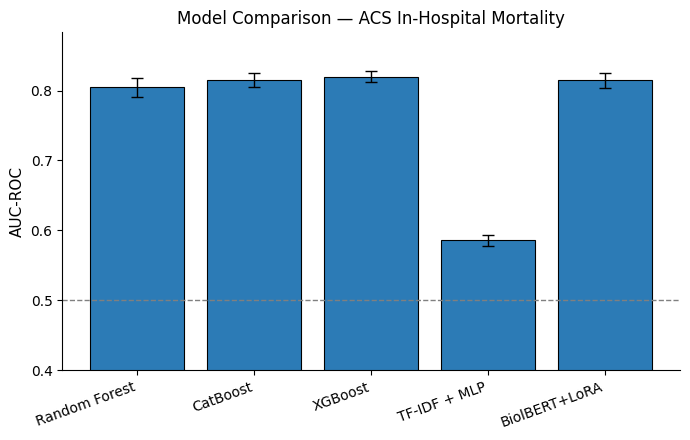

In [ ]:
# 10.1 === Comparación AUC por modelo (5-fold) - TODOS los modelos ===

model_names  = ["Random Forest", "CatBoost", "XGBoost", "TF-IDF + MLP", "BiolBERT+LoRA"]
auc_means    = [np.mean([s["auc"] for s in sc]) for sc in [rf_scores, cb_scores, xgb_scores, mlp_scores, fold_results]]
auc_stds     = [np.std( [s["auc"] for s in sc]) for sc in [rf_scores, cb_scores, xgb_scores, mlp_scores, fold_results]]

fig, ax = plt.subplots(figsize=(7, 4.5))
bars = ax.bar(model_names, auc_means, yerr=auc_stds, capsize=4,
              color="#2C7BB6", edgecolor="black", linewidth=0.8,
              error_kw=dict(elinewidth=1, ecolor="black", capthick=1))
ax.axhline(0.5, linestyle="--", linewidth=1, color="gray")
ax.set_ylabel("AUC-ROC", fontsize=11)
ax.set_ylim(0.4, min(1.0, max(auc_means) + max(auc_stds) + 0.05))
ax.set_title("Model Comparison — ACS In-Hospital Mortality", fontsize=12)
ax.spines[["top", "right"]].set_visible(False)
plt.xticks(rotation=20, ha="right", fontsize=10)
plt.tight_layout()
plt.savefig("auc_comparison_acs_mortality.pdf", bbox_inches="tight", facecolor="white")
plt.show()

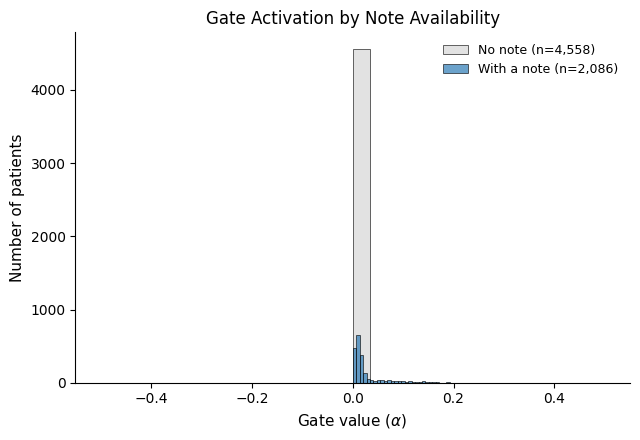

α promedio — sin nota : 0.0000 ± 0.0000
α promedio — con nota : 0.0268 ± 0.0366


In [ ]:
# 10.2 === Distribución del gate α - con vs. sin nota clínica ===

alpha_arr    = np.array(alpha_lora_all)
has_text_arr = np.array(has_text_lora_all)

alpha_sin_nota = alpha_arr[has_text_arr == 0]
alpha_con_nota = alpha_arr[has_text_arr == 1]

fig, ax = plt.subplots(figsize=(6.5, 4.5))

ax.hist(
    alpha_sin_nota, bins=30, alpha=0.7,
    label=f"No note (n={len(alpha_sin_nota):,})",
    color="#D7D7D7", edgecolor="black", linewidth=0.6
)

ax.hist(
    alpha_con_nota, bins=30, alpha=0.7,
    label=f"With a note (n={len(alpha_con_nota):,})",
    color="#2C7BB6", edgecolor="black", linewidth=0.6
)

ax.set_xlabel(r"Gate value ($\alpha$)", fontsize=11)
ax.set_ylabel("Number of patients", fontsize=11)
ax.set_title("Gate Activation by Note Availability", fontsize=12)
ax.legend(fontsize=9, frameon=False)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("gate_alpha_distribution_acs.pdf", bbox_inches="tight", facecolor="white")
plt.show()

#Resumen numérico para citar en el texto
print(f"α promedio — sin nota : {alpha_sin_nota.mean():.4f} ± {alpha_sin_nota.std():.4f}")
print(f"α promedio — con nota : {alpha_con_nota.mean():.4f} ± {alpha_con_nota.std():.4f}")

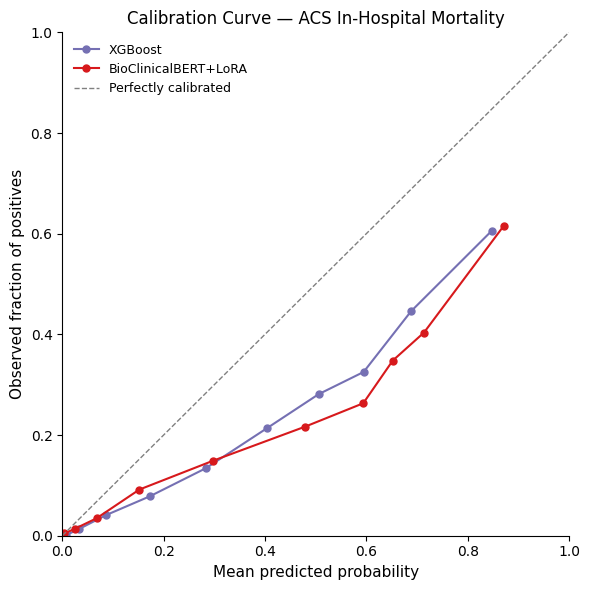

In [ ]:
# 10.3 === Curva de calibración — XGBoost vs. BioBERT-LoRA ===

from sklearn.calibration import calibration_curve

fig, ax = plt.subplots(figsize=(6, 6))

for name, y_true, y_proba, color in [
    ("XGBoost",              y_true_xgb_all,  y_proba_xgb_all,  "#7570B3"),
    ("BioClinicalBERT+LoRA", y_true_lora_all, y_proba_lora_all, "#D7191C"),
]:
    frac_pos, mean_pred = calibration_curve(y_true, y_proba, n_bins=10, strategy="quantile")
    ax.plot(mean_pred, frac_pos, marker="o", markersize=5,
            label=name, color=color, linewidth=1.5)

ax.plot([0, 1], [0, 1], linestyle="--", color="gray", linewidth=1, label="Perfectly calibrated")

ax.set_xlabel("Mean predicted probability", fontsize=11)
ax.set_ylabel("Observed fraction of positives", fontsize=11)
ax.set_title("Calibration Curve — ACS In-Hospital Mortality", fontsize=12)
ax.legend(fontsize=9, frameon=False, loc="upper left")
ax.spines[["top", "right"]].set_visible(False)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

plt.tight_layout()
plt.savefig("calibration_curve_acs.pdf", bbox_inches="tight", facecolor="white")
plt.show()

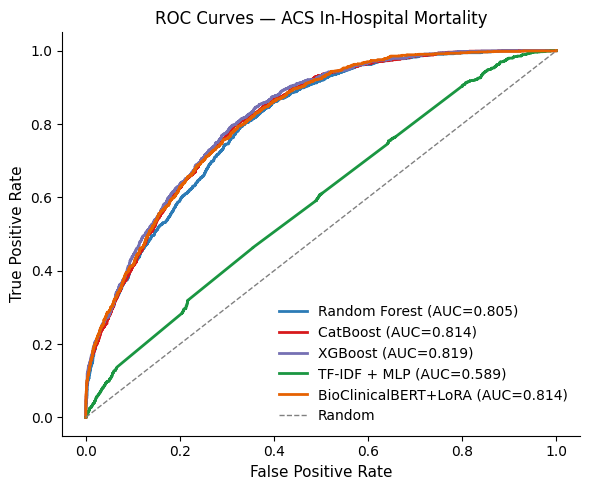

In [ ]:
# 10.4  Gráfico ROC curves de todos los modelos

#Usa las predicciones out-of-fold acumuladas en los 5 folds

#Incluye:
# - Random Forest
# - CatBoost
# - XGBoost
# - TF-IDF + MLP
# - BioBERT+LoRA

!pip -q install matplotlib

fig, ax = plt.subplots(figsize=(6, 5))

models_to_plot = [
    ("Random Forest",         y_true_rf_all,   y_proba_rf_all,   "#2C7BB6"),
    ("CatBoost",              y_true_cb_all,   y_proba_cb_all,   "#D7191C"),
    ("XGBoost",               y_true_xgb_all,  y_proba_xgb_all,  "#7570B3"),
    ("TF-IDF + MLP",          y_true_mlp_all,  y_proba_mlp_all,  "#1A9641"),
    ("BioClinicalBERT+LoRA",  y_true_lora_all, y_proba_lora_all, "#E66101"),
]

for label, y_t, y_p, color in models_to_plot:

    y_t = np.asarray(y_t)
    y_p = np.asarray(y_p)

    #Evitar errores si algún modelo no generó predicciones válidas
    if len(y_t) == 0 or len(y_p) == 0:
        print(f"{label}: sin predicciones, se omite en ROC.")
        continue

    if len(np.unique(y_t)) < 2:
        print(f"{label}: y_true tiene una sola clase, se omite en ROC.")
        continue

    fpr, tpr, _ = roc_curve(y_t, y_p)
    auc_val = auc(fpr, tpr)

    ax.plot(
        fpr,
        tpr,
        linewidth=2,
        color=color,
        label=f"{label} (AUC={auc_val:.3f})"
    )

#Línea diagonal de clasificador aleatorio
ax.plot(
    [0, 1],
    [0, 1],
    "--",
    color="gray",
    linewidth=1,
    label="Random"
)

ax.set_xlabel("False Positive Rate", fontsize=11)
ax.set_ylabel("True Positive Rate", fontsize=11)
ax.set_title("ROC Curves — ACS In-Hospital Mortality", fontsize=12)

ax.legend(frameon=False, fontsize=10)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()

plt.savefig(
    "roc_curves_acs_mortality.pdf",
    bbox_inches="tight",
    facecolor="white"
)

plt.show()